**Import advanced Python libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import warnings
import re
from collections import Counter

warnings.filterwarnings('ignore')


**Global Style**

In [ ]:
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

PALETTE = ["#3B82F6","#10B981","#F59E0B","#EF4444","#8B5CF6",
           "#EC4899","#14B8A6","#F97316","#6366F1","#84CC16"]


**Load data**

In [ ]:
df = pd.read_csv("mobile_reviews.csv")

# Derived columns
df["price_band"] = pd.cut(df["price_inr"],
    bins=[0,20000,40000,70000,120000,200000],
    labels=["Budget\n(<20K)","Mid-Range\n(20–40K)","Upper-Mid\n(40–70K)","Premium\n(70–120K)","Flagship\n(>120K)"])
df["age_group"] = pd.cut(df["age"], bins=[17,25,35,45,55,100],
    labels=["18–25","26–35","36–45","46–55","55+"])
df["sentiment"] = df["rating"].map({1:"Negative",2:"Negative",3:"Neutral",4:"Positive",5:"Positive"})
df["review_length"] = df["review_text"].str.split().str.len()

print(df.head())
#OUT = "/mnt/user-data/outputs/"


    customer_name  age  gender         occupation   brand  \
0   Aarav Trivedi   35    Male         Accountant  Xiaomi   
1     Aarav Singh   31    Male         Accountant    iQOO   
2  Bhavna Agarwal   18  Female  Marketing Manager  Realme   
3      Pooja Iyer   40  Female             Lawyer    Vivo   
4   Bhavna Mishra   22  Female            Student  Xiaomi   

                 model  price_inr      platform  \
0   Redmi Note 13 Pro+      29999      Flipkart   
1              iQOO 12      52999   Apple Store   
2  Realme Narzo 60 Pro      23999         Croma   
3        Vivo X100 Pro      89999  Samsung Shop   
4        Redmi Note 13      17999      Flipkart   

                                         review_text  rating  \
0  Best phone under this budget. Beats competitor...       5   
1  Love the display and performance. Battery drai...       3   
2  Great for daily use. Gaming heats it up a bit ...       3   
3  The stereo speakers are incredibly loud and cl...       4   
4  Sup

# STEP 1 DATASET OVERVIEW (EDA Summary)

STEP 1 – Dataset Overview


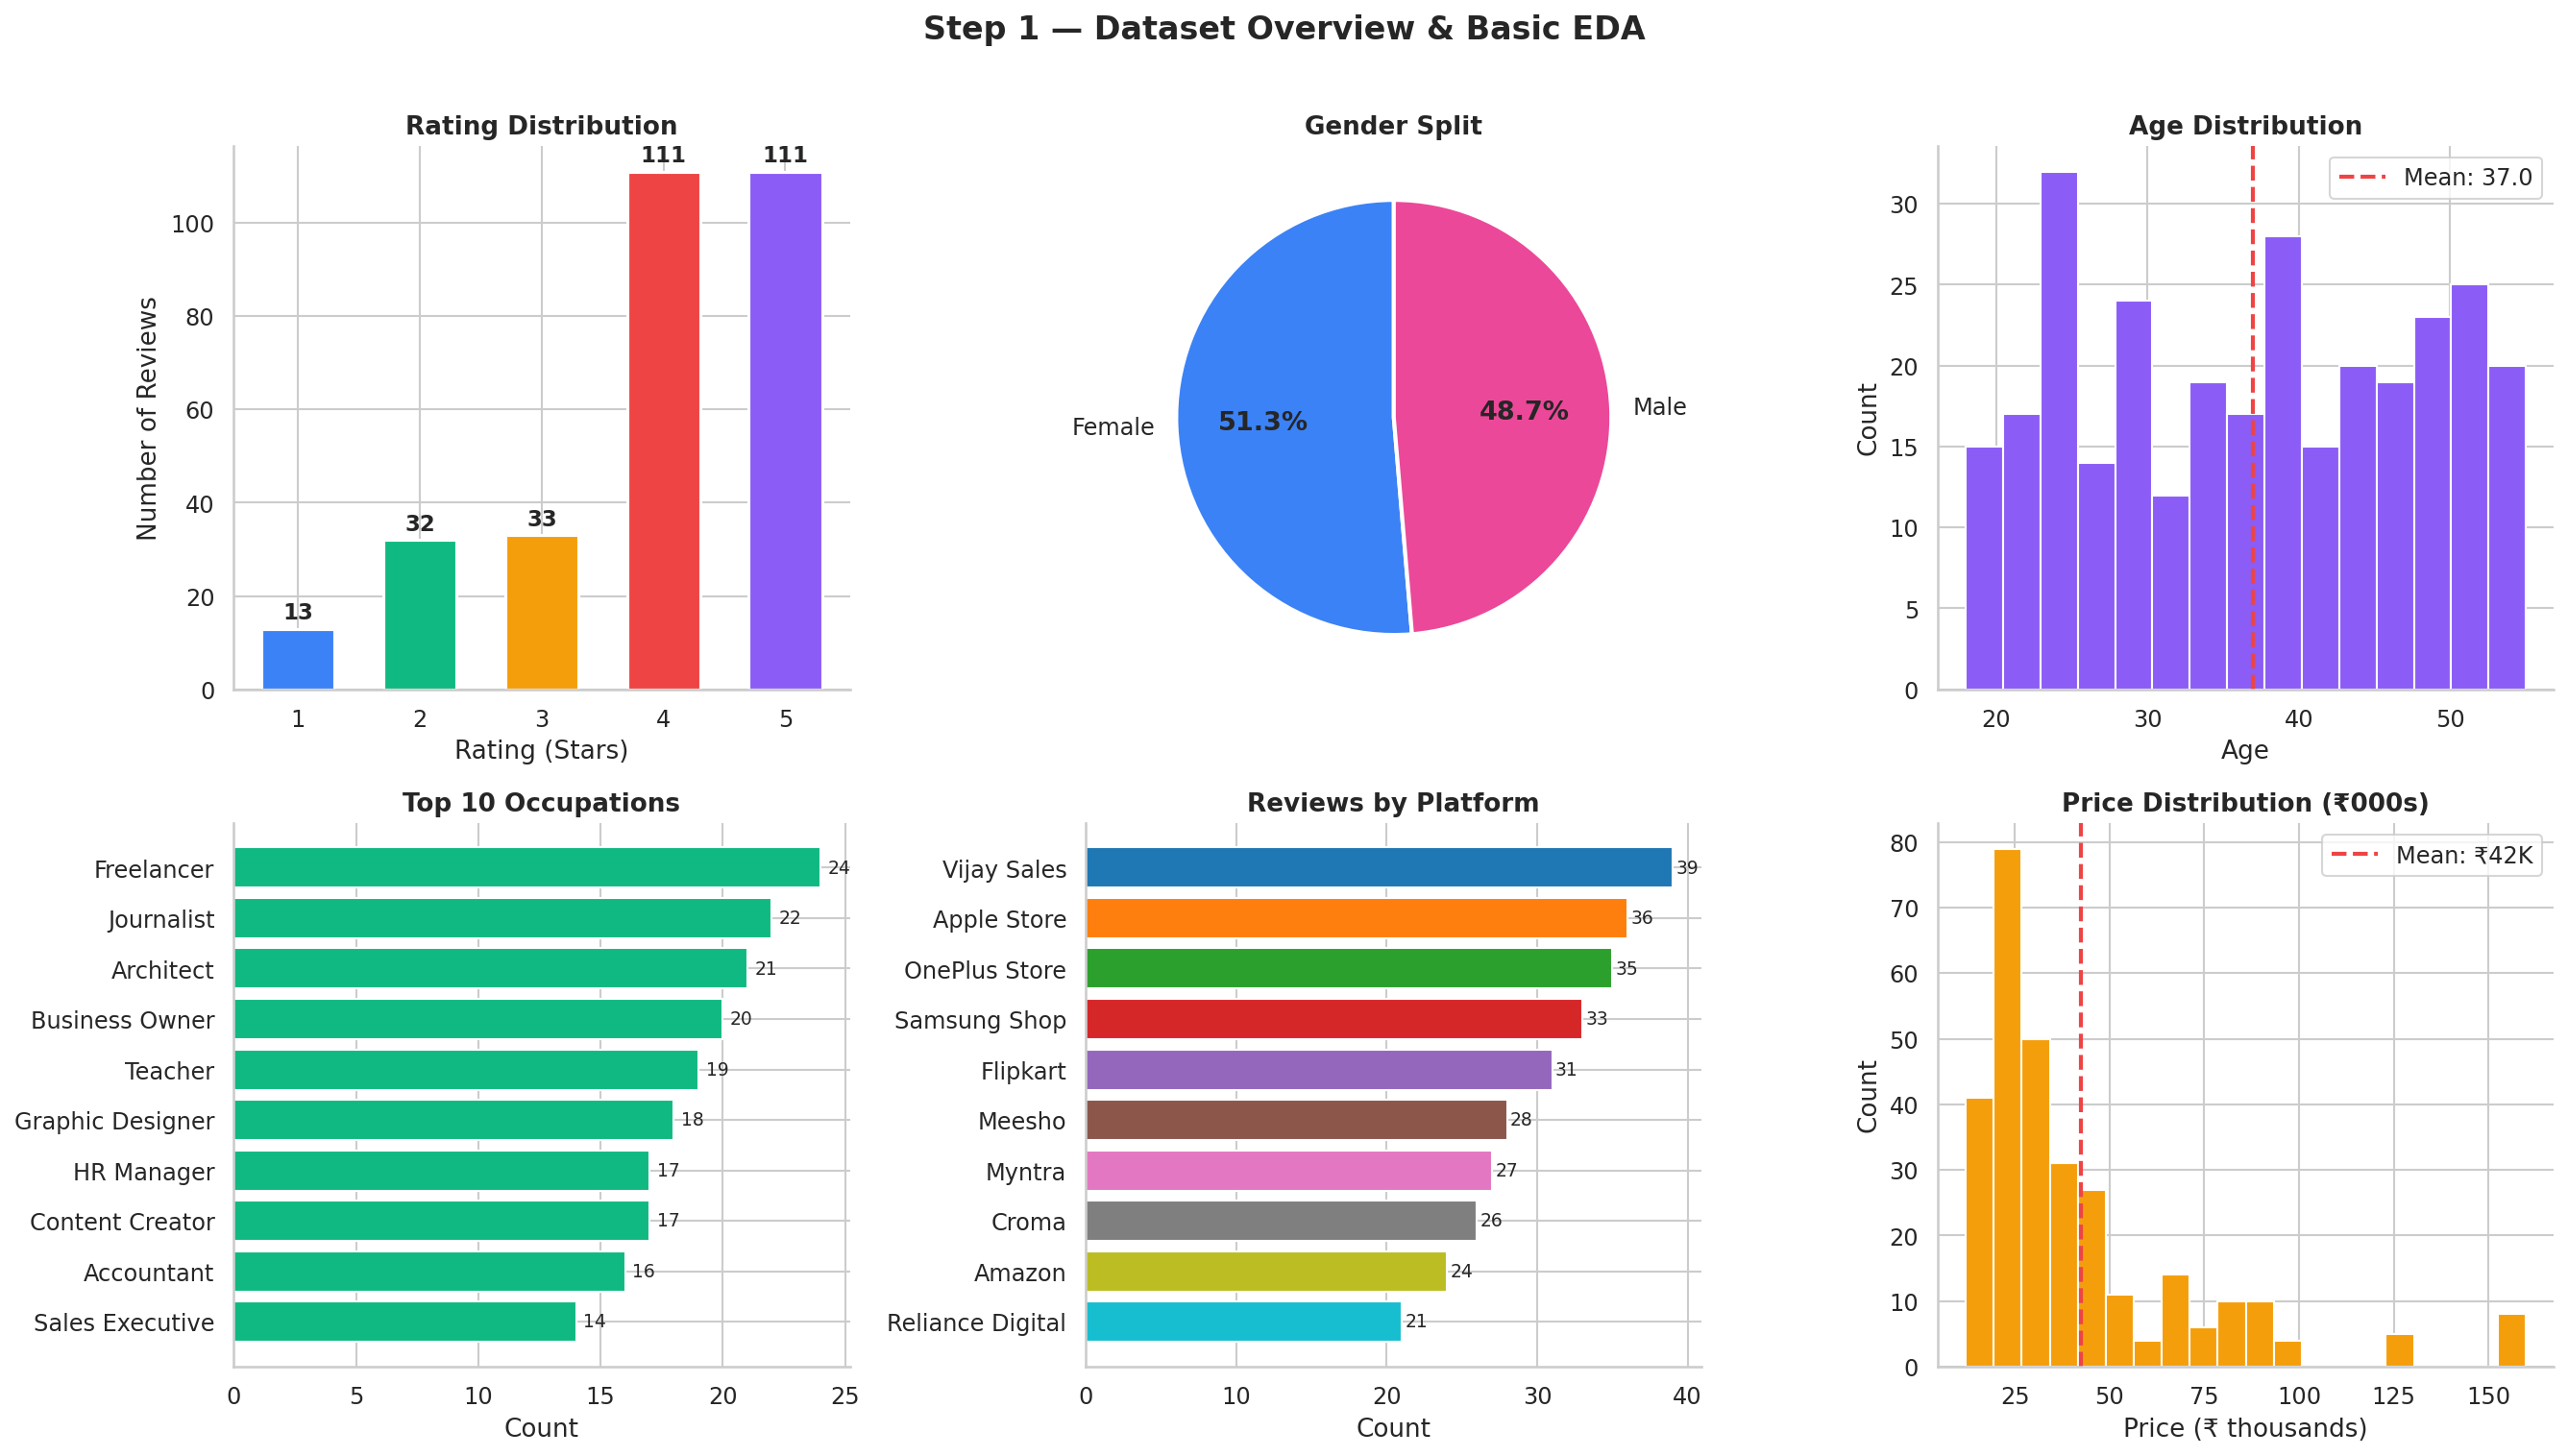

  ✓ step1_overview.png


In [ ]:
print("STEP 1 – Dataset Overview")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Step 1 — Dataset Overview & Basic EDA", fontsize=16, fontweight="bold", y=1.01)
# 1a Rating distribution
ax = axes[0,0]
counts = df["rating"].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=PALETTE[:5], edgecolor="white", linewidth=1.5, width=0.6)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, str(int(b.get_height())),
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Rating Distribution", fontweight="bold")
ax.set_xlabel("Rating (Stars)"); ax.set_ylabel("Number of Reviews")
ax.set_xticks([1,2,3,4,5])

# 1b Gender split pie
ax = axes[0,1]
gc = df["gender"].value_counts()
wedges, texts, autotexts = ax.pie(gc, labels=gc.index, autopct="%1.1f%%",
    colors=["#3B82F6","#EC4899"], startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2))
for t in autotexts: t.set_fontsize(13); t.set_fontweight("bold")
ax.set_title("Gender Split", fontweight="bold")

# 1c Age distribution
ax = axes[0,2]
ax.hist(df["age"], bins=15, color="#8B5CF6", edgecolor="white", linewidth=1)
ax.axvline(df["age"].mean(), color="#EF4444", linestyle="--", linewidth=2, label=f'Mean: {df["age"].mean():.1f}')
ax.set_title("Age Distribution", fontweight="bold")
ax.set_xlabel("Age"); ax.set_ylabel("Count")
ax.legend()

# 1d Top occupations
ax = axes[1,0]
top_occ = df["occupation"].value_counts().head(10)
ax.barh(top_occ.index[::-1], top_occ.values[::-1], color="#10B981", edgecolor="white")
for i, v in enumerate(top_occ.values[::-1]):
    ax.text(v+0.3, i, str(v), va="center", fontsize=9)
ax.set_title("Top 10 Occupations", fontweight="bold")
ax.set_xlabel("Count")

# 1e Platform share
ax = axes[1,1]
plat = df["platform"].value_counts()
colors_p = sns.color_palette("tab10", len(plat))
ax.barh(plat.index[::-1], plat.values[::-1], color=colors_p[::-1])
for i, v in enumerate(plat.values[::-1]):
    ax.text(v+0.2, i, str(v), va="center", fontsize=9)
ax.set_title("Reviews by Platform", fontweight="bold")
ax.set_xlabel("Count")

# 1f Price distribution
ax = axes[1,2]
ax.hist(df["price_inr"]/1000, bins=20, color="#F59E0B", edgecolor="white")
ax.set_title("Price Distribution (₹000s)", fontweight="bold")
ax.set_xlabel("Price (₹ thousands)"); ax.set_ylabel("Count")
ax.axvline(df["price_inr"].mean()/1000, color="#EF4444", linestyle="--", linewidth=2,
           label=f'Mean: ₹{df["price_inr"].mean()/1000:.0f}K')
ax.legend()

plt.tight_layout()
#plt.savefig(OUT+"step1_overview.png", bbox_inches="tight")
plt.show()
plt.close()
print("  ✓ step1_overview.png")


# STEP 2  BRAND ANALYSIS

STEP 2 – Brand Analysis


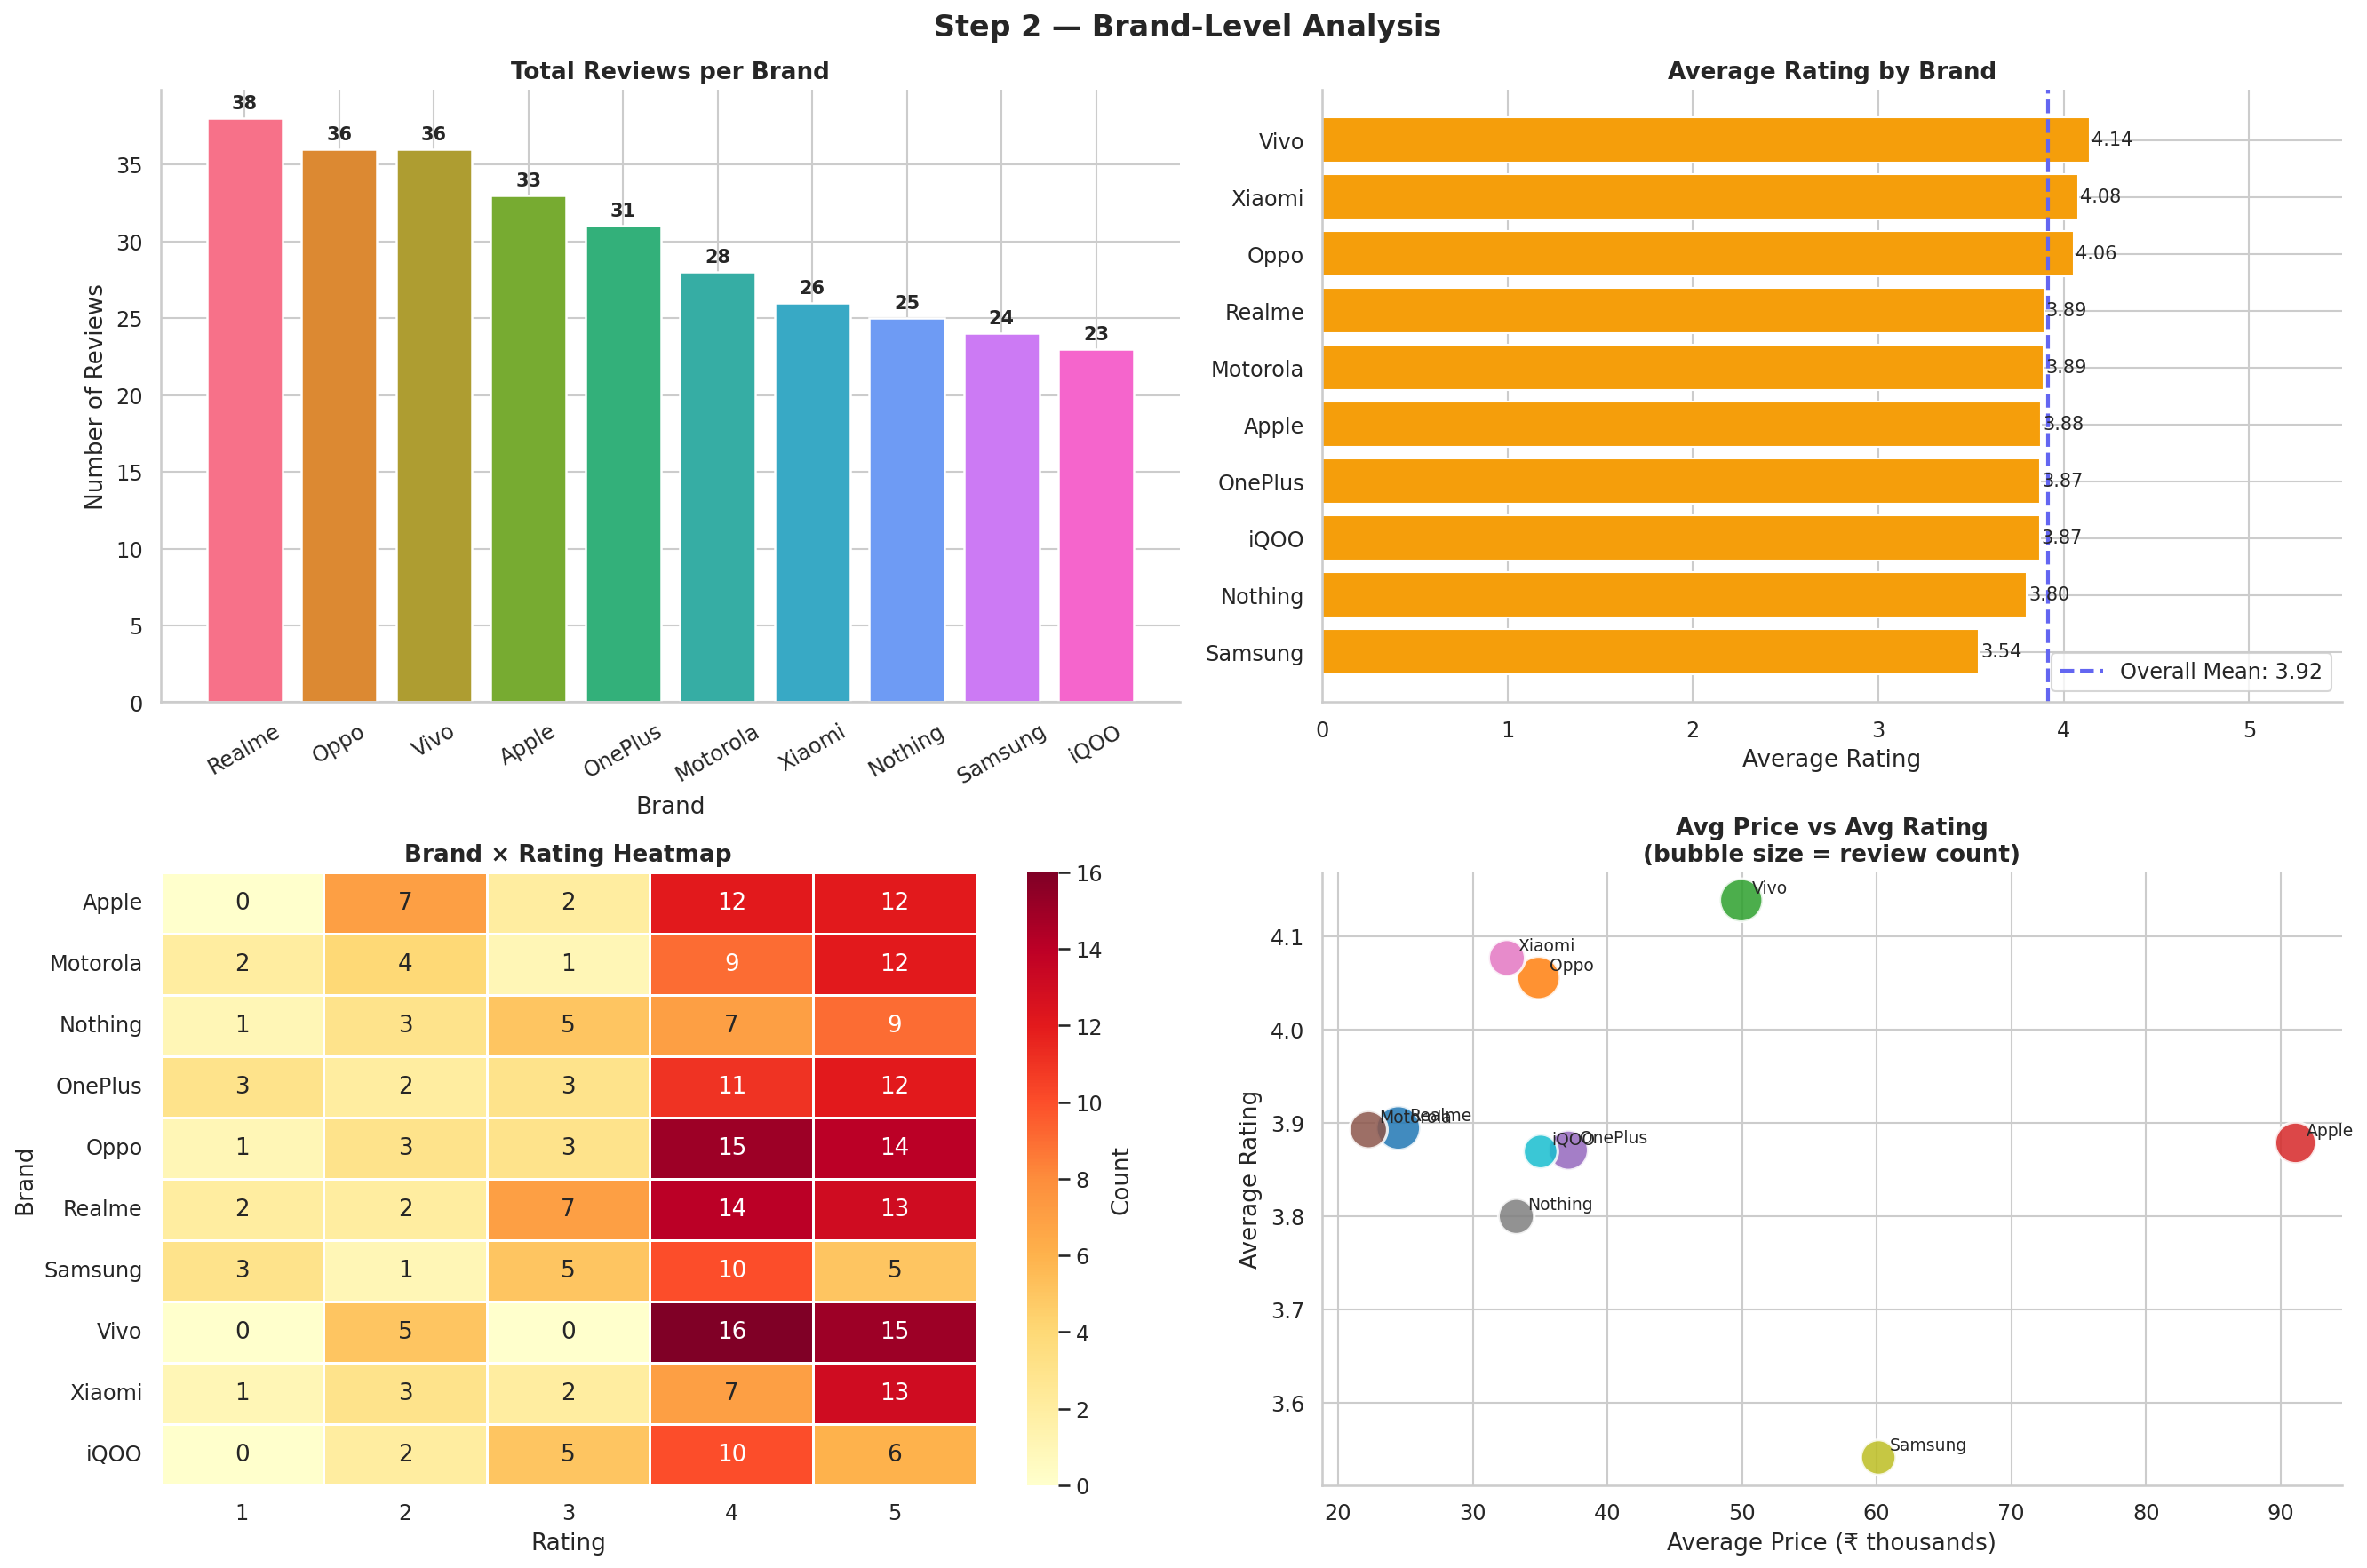

  ✓ step2_brand_analysis.png


In [ ]:
print("STEP 2 – Brand Analysis")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Step 2 — Brand-Level Analysis", fontsize=16, fontweight="bold")

brand_stats = df.groupby("brand").agg(
    reviews=("rating","count"),
    avg_rating=("rating","mean"),
    avg_price=("price_inr","mean")
).reset_index().sort_values("reviews", ascending=False)

# 2a Review count by brand
ax = axes[0,0]
colors_b = sns.color_palette("husl", len(brand_stats))
bars = ax.bar(brand_stats["brand"], brand_stats["reviews"], color=colors_b, edgecolor="white", linewidth=1.2)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.4, str(int(b.get_height())),
            ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Total Reviews per Brand", fontweight="bold")
ax.set_ylabel("Number of Reviews"); ax.set_xlabel("Brand")
ax.tick_params(axis="x", rotation=30)

# 2b Average rating by brand
ax = axes[0,1]
brand_sorted = brand_stats.sort_values("avg_rating", ascending=True)
bar_colors = ["#EF4444" if r < 3.5 else "#F59E0B" if r < 4.2 else "#10B981" for r in brand_sorted["avg_rating"]]
bars = ax.barh(brand_sorted["brand"], brand_sorted["avg_rating"], color=bar_colors, edgecolor="white")
ax.axvline(df["rating"].mean(), color="#6366F1", linestyle="--", linewidth=2,
           label=f'Overall Mean: {df["rating"].mean():.2f}')
for b in bars:
    w = b.get_width()
    ax.text(w+0.01, b.get_y()+b.get_height()/2, f'{w:.2f}', va="center", fontsize=10)
ax.set_title("Average Rating by Brand", fontweight="bold")
ax.set_xlabel("Average Rating"); ax.set_xlim(0, 5.5)
ax.legend()

# 2c Rating heatmap (brand × rating)
ax = axes[1,0]
hm = df.groupby(["brand","rating"]).size().unstack(fill_value=0)
sns.heatmap(hm, annot=True, fmt="d", cmap="YlOrRd", ax=ax,
            linewidths=0.5, linecolor="white", cbar_kws={"label":"Count"})
ax.set_title("Brand × Rating Heatmap", fontweight="bold")
ax.set_xlabel("Rating"); ax.set_ylabel("Brand")

# 2d Avg price vs avg rating scatter
ax = axes[1,1]
scatter = ax.scatter(brand_stats["avg_price"]/1000, brand_stats["avg_rating"],
                     s=brand_stats["reviews"]*15, c=range(len(brand_stats)),
                     cmap="tab10", alpha=0.85, edgecolors="white", linewidth=1.5)
for _, row in brand_stats.iterrows():
    ax.annotate(row["brand"], (row["avg_price"]/1000, row["avg_rating"]),
                textcoords="offset points", xytext=(6,4), fontsize=9)
ax.set_title("Avg Price vs Avg Rating\n(bubble size = review count)", fontweight="bold")
ax.set_xlabel("Average Price (₹ thousands)"); ax.set_ylabel("Average Rating")

plt.tight_layout()
plt.show()
#plt.savefig(OUT+"step2_brand_analysis.png", bbox_inches="tight")
plt.close()
print("  ✓ step2_brand_analysis.png")


# STEP 3  RATING DEEP DIVE

STEP 3 – Rating Deep Dive


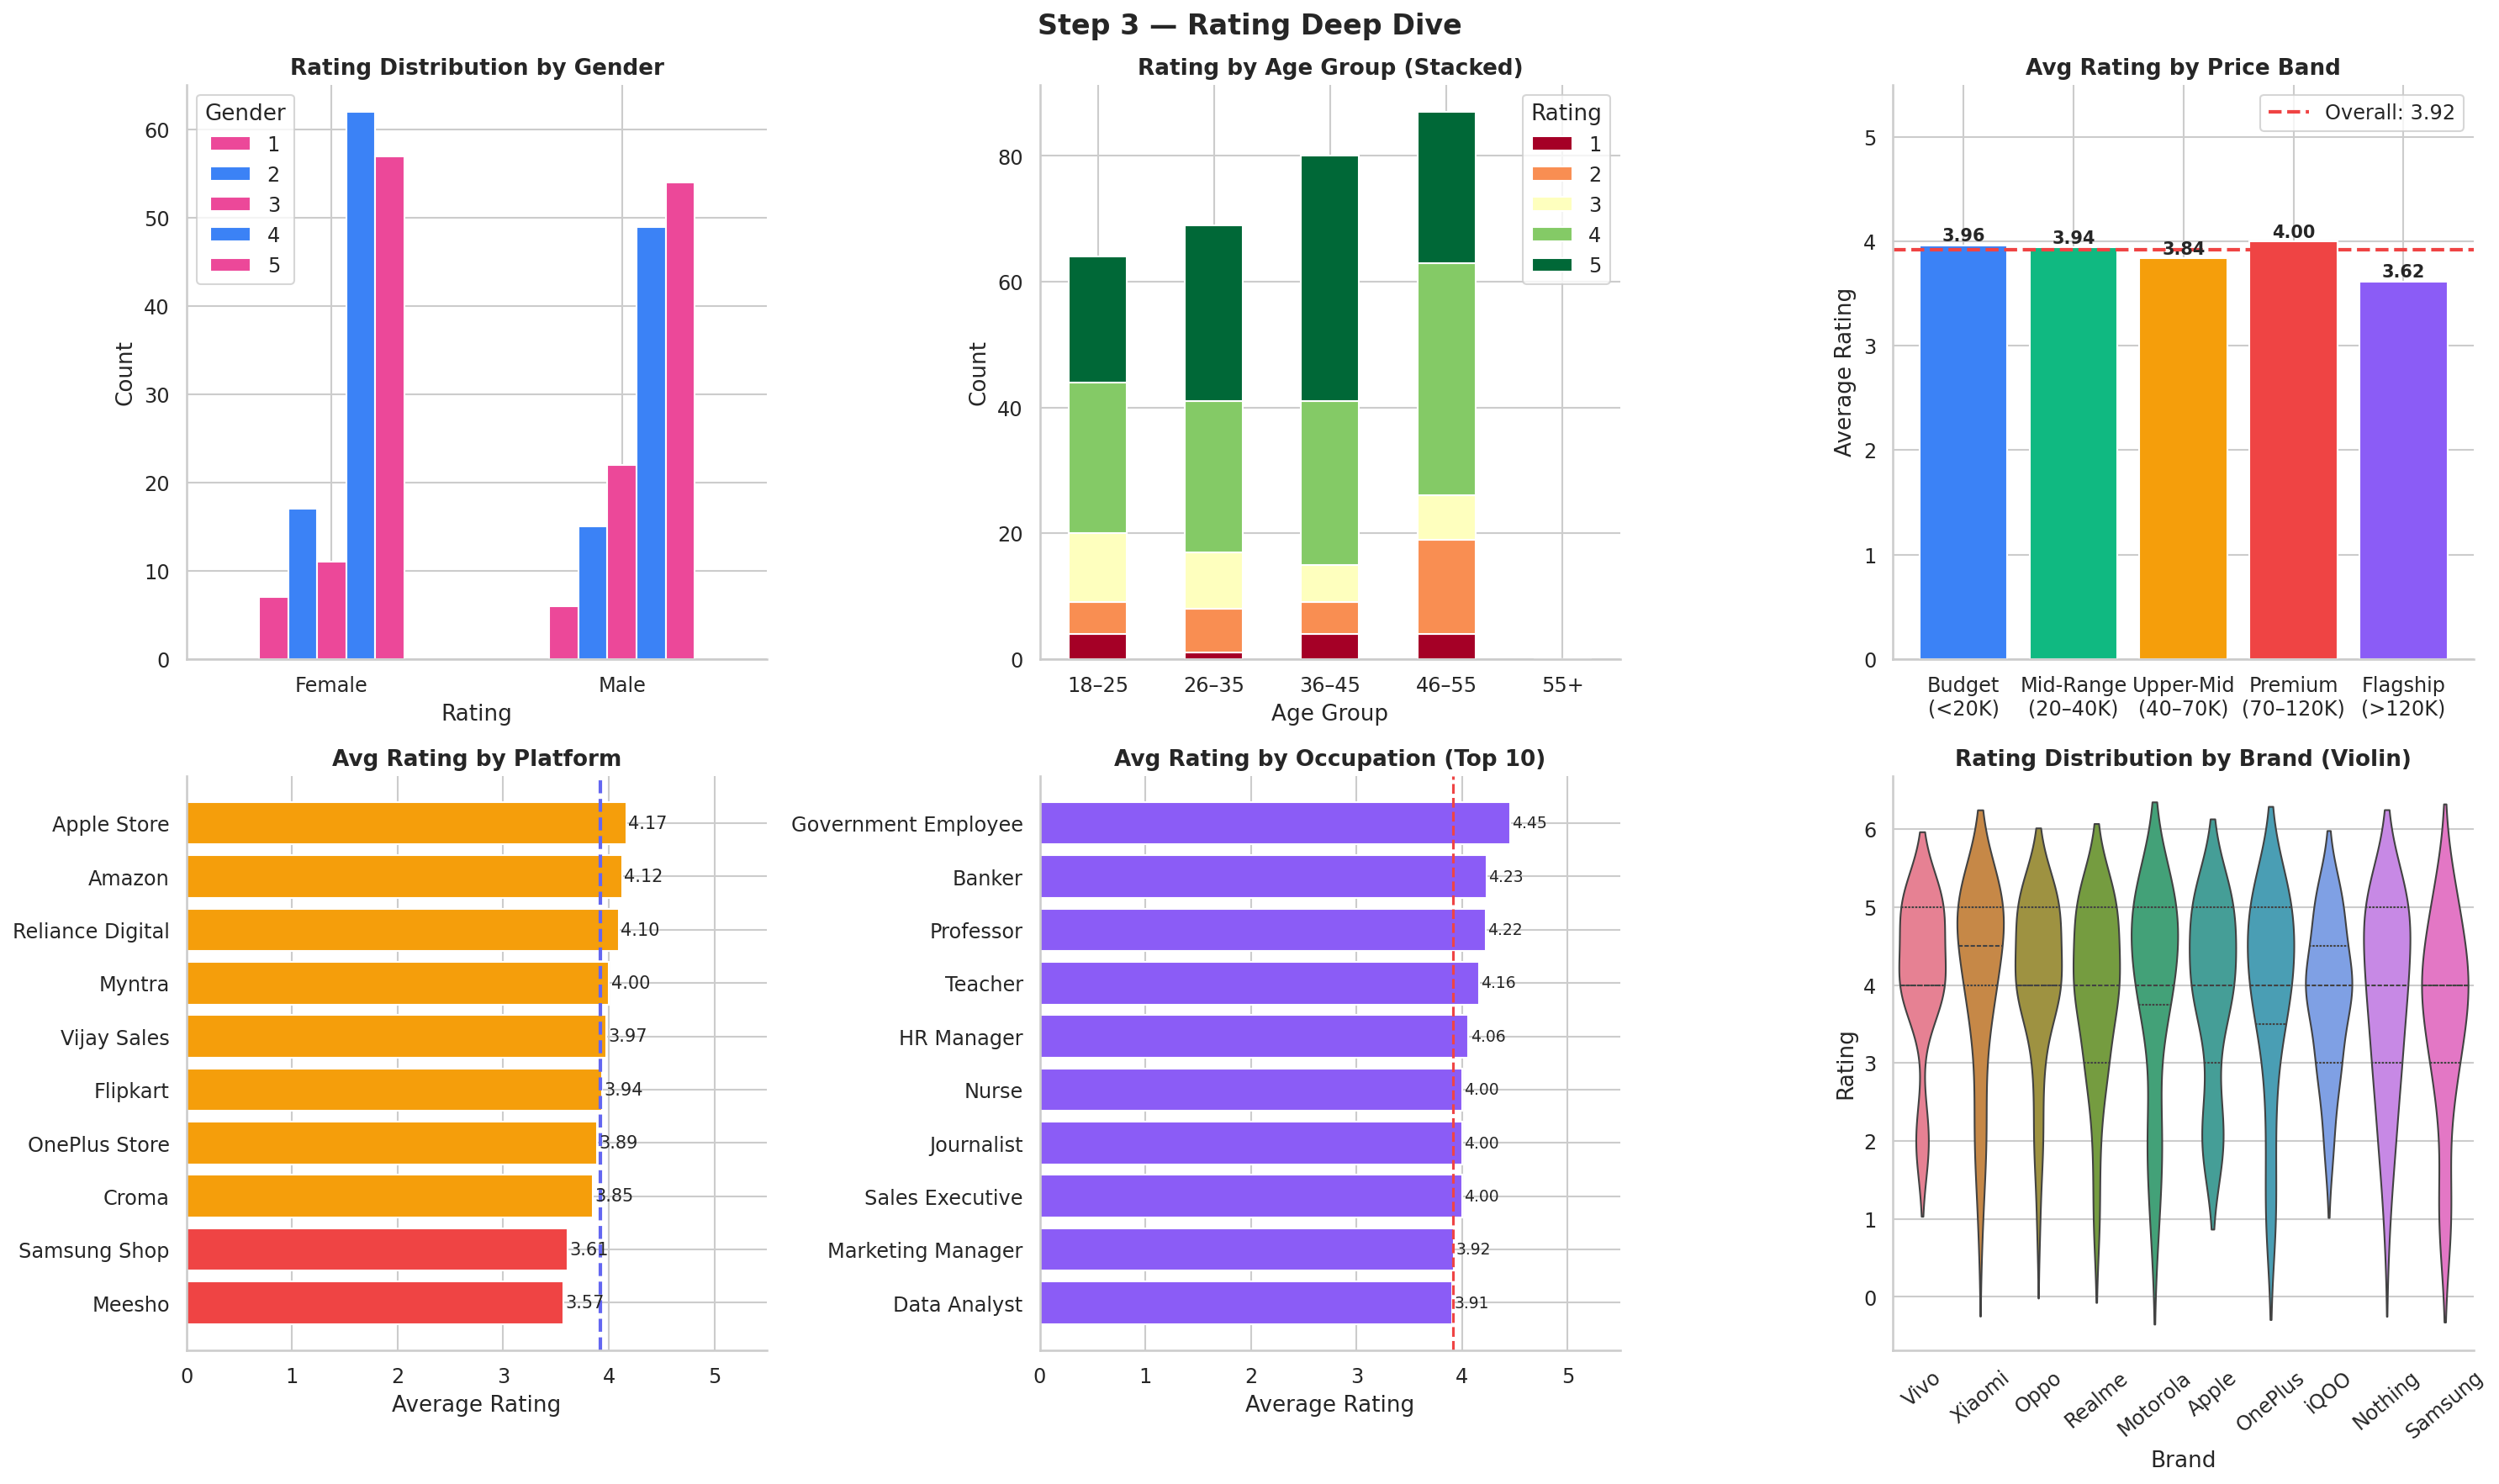

  ✓ step3_rating_deepdive.png


In [ ]:
print("STEP 3 – Rating Deep Dive")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Step 3 — Rating Deep Dive", fontsize=16, fontweight="bold")

# 3a Rating by gender
ax = axes[0,0]
df.groupby(["gender","rating"]).size().unstack().plot(kind="bar", ax=ax,
    color=["#EC4899","#3B82F6"], edgecolor="white", rot=0)
ax.set_title("Rating Distribution by Gender", fontweight="bold")
ax.set_xlabel("Rating"); ax.set_ylabel("Count")
ax.legend(title="Gender")

# 3b Rating by age group
ax = axes[0,1]
ag_pivot = df.groupby(["age_group","rating"]).size().unstack(fill_value=0)
ag_pivot.plot(kind="bar", stacked=True, ax=ax,
    colormap="RdYlGn", edgecolor="white", rot=0)
ax.set_title("Rating by Age Group (Stacked)", fontweight="bold")
ax.set_xlabel("Age Group"); ax.set_ylabel("Count")
ax.legend(title="Rating", bbox_to_anchor=(1,1))

# 3c Rating by price band
ax = axes[0,2]
pb_mean = df.groupby("price_band")["rating"].mean().reset_index()
bars = ax.bar(pb_mean["price_band"].astype(str), pb_mean["rating"],
              color=PALETTE[:5], edgecolor="white")
ax.axhline(df["rating"].mean(), color="#EF4444", linestyle="--", linewidth=2,
           label=f'Overall: {df["rating"].mean():.2f}')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.04,
            f'{b.get_height():.2f}', ha="center", fontsize=10, fontweight="bold")
ax.set_title("Avg Rating by Price Band", fontweight="bold")
ax.set_ylabel("Average Rating"); ax.set_ylim(0, 5.5)
ax.legend()

# 3d Rating by platform
ax = axes[1,0]
plat_rating = df.groupby("platform")["rating"].mean().sort_values(ascending=True)
colors_pr = ["#EF4444" if r<3.8 else "#F59E0B" if r<4.2 else "#10B981" for r in plat_rating]
ax.barh(plat_rating.index, plat_rating.values, color=colors_pr, edgecolor="white")
for i, v in enumerate(plat_rating.values):
    ax.text(v+0.02, i, f'{v:.2f}', va="center", fontsize=10)
ax.set_title("Avg Rating by Platform", fontweight="bold")
ax.set_xlabel("Average Rating"); ax.set_xlim(0, 5.5)
ax.axvline(df["rating"].mean(), color="#6366F1", linestyle="--", linewidth=2)

# 3e Rating by occupation (top 10)
ax = axes[1,1]
occ_rating = df.groupby("occupation")["rating"].mean().sort_values(ascending=False).head(10)
ax.barh(occ_rating.index[::-1], occ_rating.values[::-1], color="#8B5CF6", edgecolor="white")
ax.axvline(df["rating"].mean(), color="#EF4444", linestyle="--", linewidth=1.5)
for i, v in enumerate(occ_rating.values[::-1]):
    ax.text(v+0.02, i, f'{v:.2f}', va="center", fontsize=9)
ax.set_title("Avg Rating by Occupation (Top 10)", fontweight="bold")
ax.set_xlabel("Average Rating"); ax.set_xlim(0, 5.5)

# 3f Violin plot – rating distribution by brand
ax = axes[1,2]
brand_order = df.groupby("brand")["rating"].mean().sort_values(ascending=False).index
sns.violinplot(data=df, x="brand", y="rating", ax=ax, order=brand_order,
               palette="husl", inner="quartile", linewidth=1)
ax.set_title("Rating Distribution by Brand (Violin)", fontweight="bold")
ax.set_xlabel("Brand"); ax.set_ylabel("Rating")
ax.tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()
#plt.savefig(OUT+"step3_rating_deepdive.png", bbox_inches="tight")
plt.close()
print("  ✓ step3_rating_deepdive.png")


# STEP 4  CUSTOMER DEMOGRAPHICS

STEP 4 – Customer Demographics


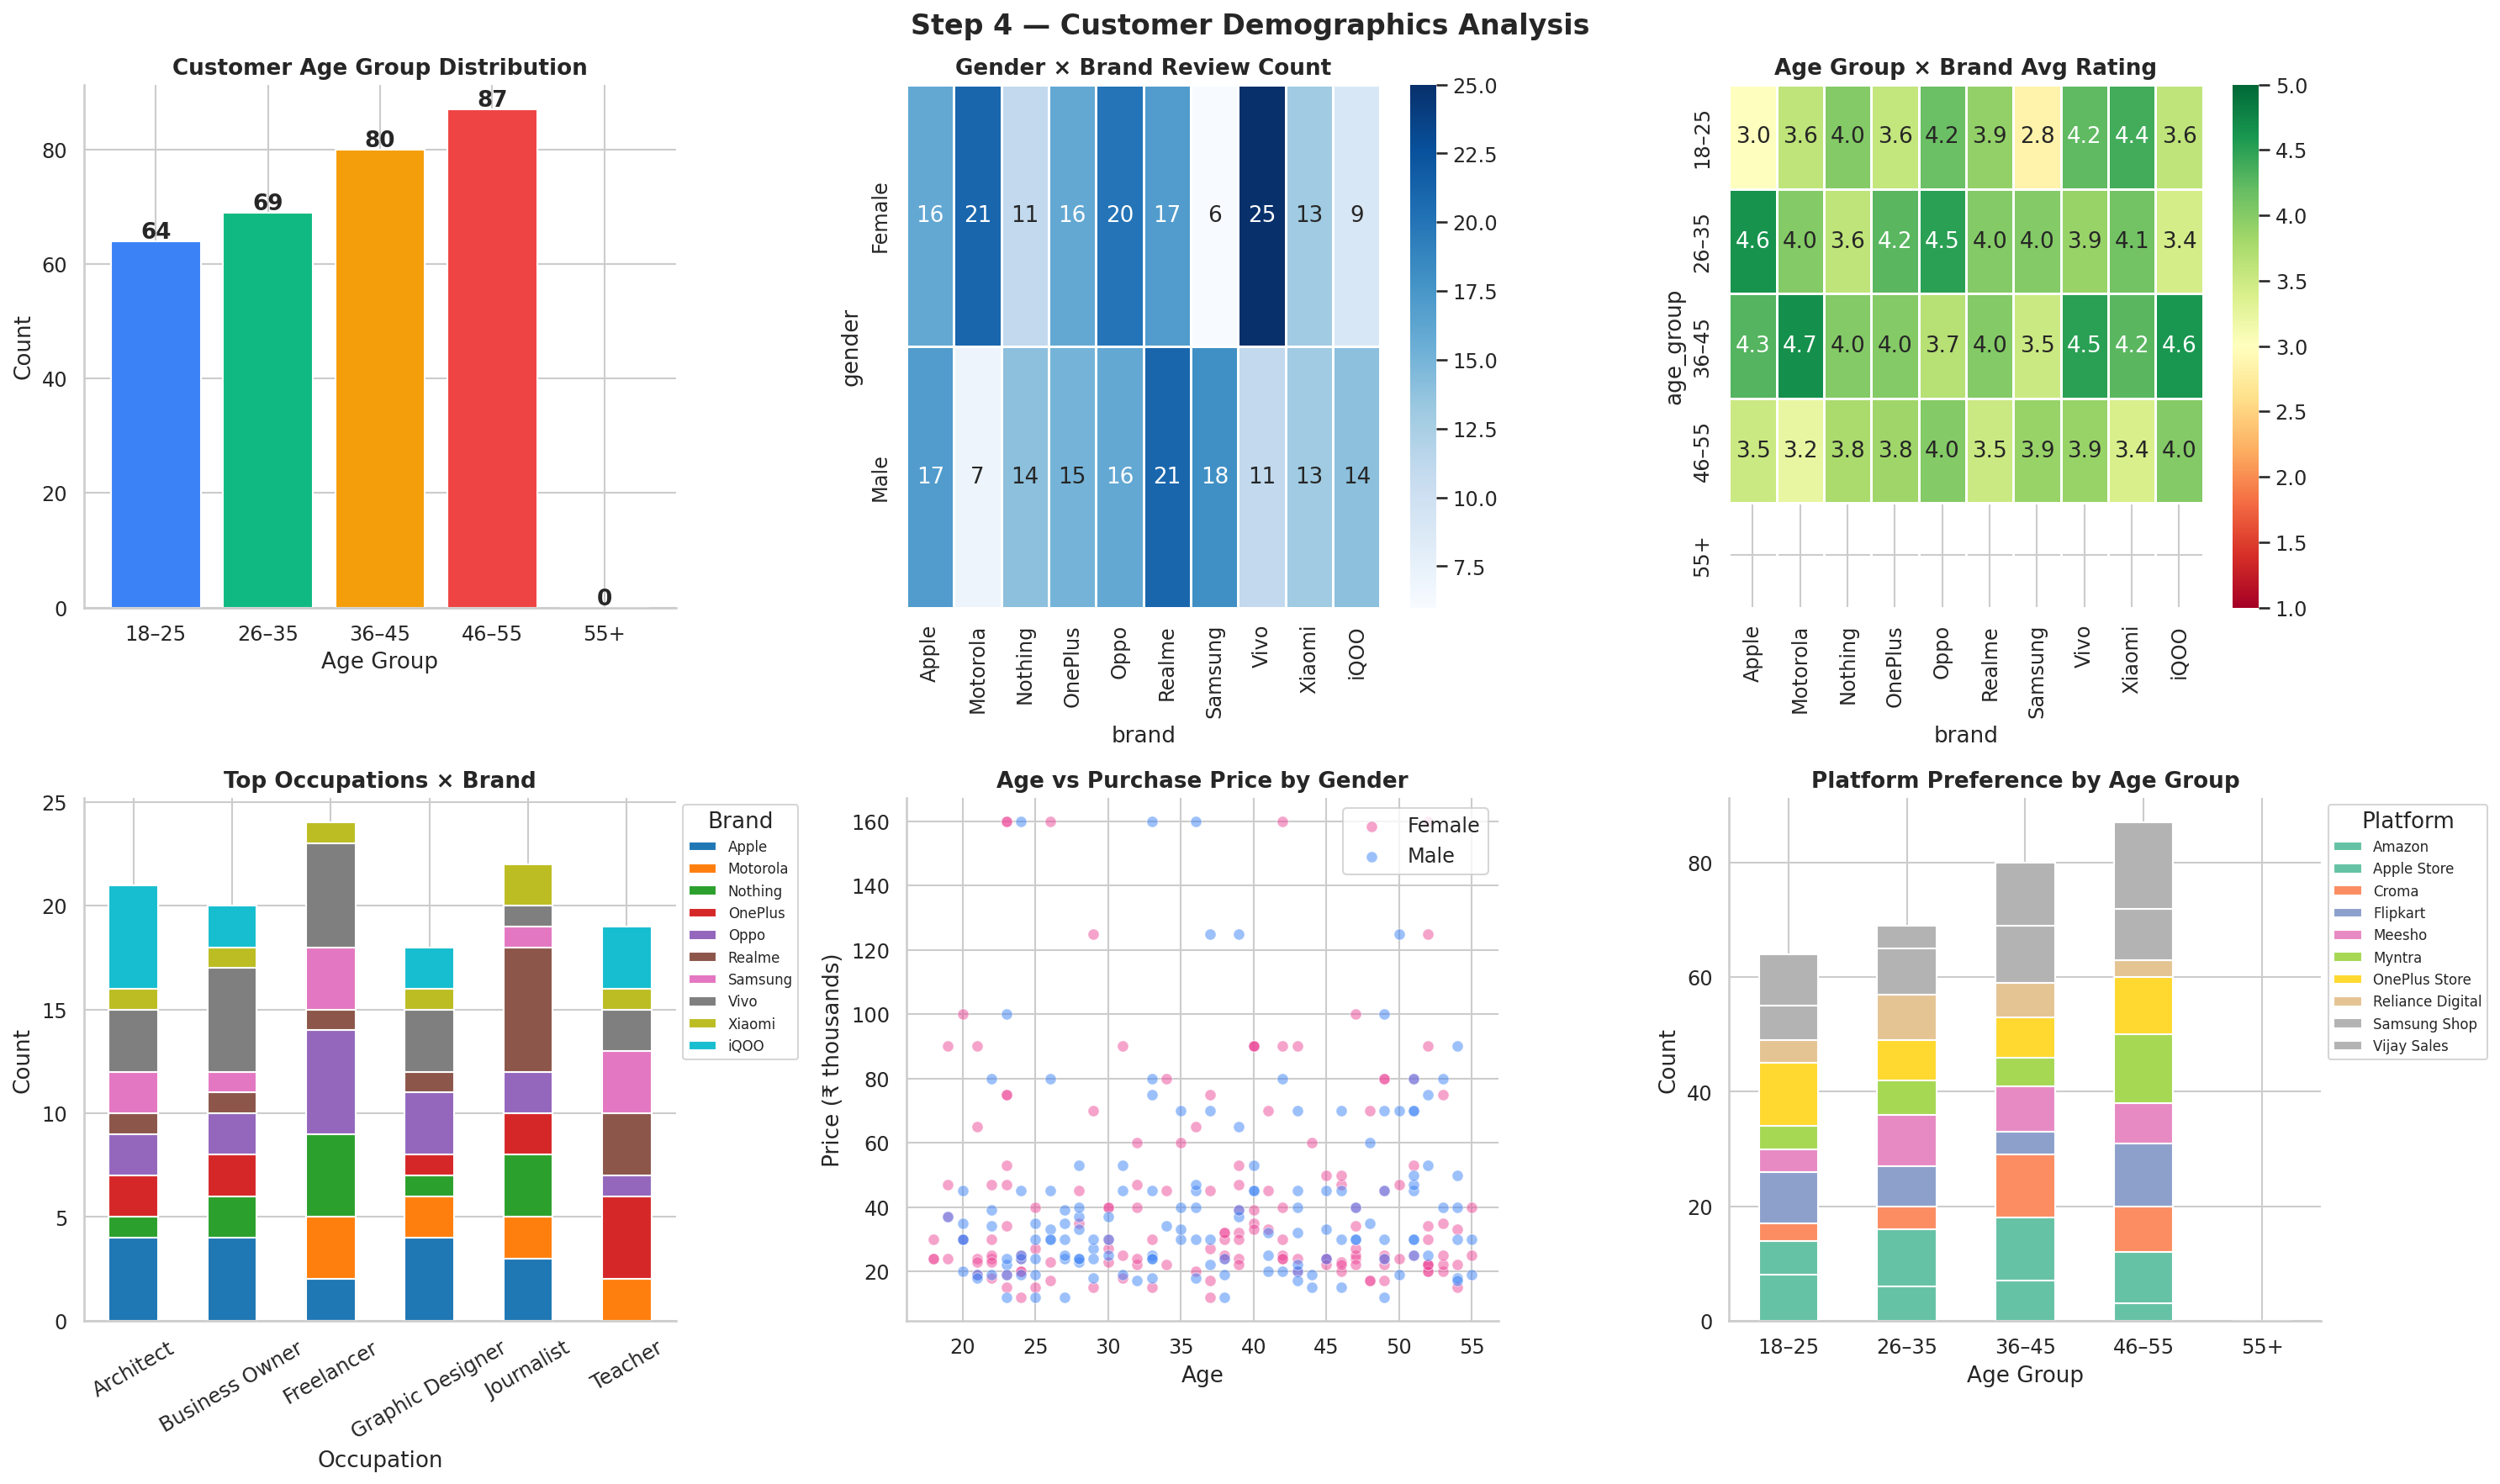

  ✓ step4_demographics.png


In [ ]:
print("STEP 4 – Customer Demographics")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Step 4 — Customer Demographics Analysis", fontsize=16, fontweight="bold")

# 4a Age group distribution
ax = axes[0,0]
ag_counts = df["age_group"].value_counts().sort_index()
ax.bar(ag_counts.index, ag_counts.values, color=PALETTE[:5], edgecolor="white")
for i, v in enumerate(ag_counts.values):
    ax.text(i, v+0.5, str(v), ha="center", fontweight="bold")
ax.set_title("Customer Age Group Distribution", fontweight="bold")
ax.set_xlabel("Age Group"); ax.set_ylabel("Count")

# 4b Gender × Brand heatmap
ax = axes[0,1]
gb_hm = df.groupby(["gender","brand"]).size().unstack(fill_value=0)
sns.heatmap(gb_hm, annot=True, fmt="d", cmap="Blues", ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_title("Gender × Brand Review Count", fontweight="bold")

# 4c Age group × brand avg rating
ax = axes[0,2]
ag_br = df.groupby(["age_group","brand"])["rating"].mean().unstack()
sns.heatmap(ag_br, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax,
            linewidths=0.5, linecolor="white", vmin=1, vmax=5)
ax.set_title("Age Group × Brand Avg Rating", fontweight="bold")

# 4d Top occupations by brand (stacked bar)
ax = axes[1,0]
top5_occ = df["occupation"].value_counts().head(6).index
occ_brand = df[df["occupation"].isin(top5_occ)].groupby(["occupation","brand"]).size().unstack(fill_value=0)
occ_brand.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", edgecolor="white", rot=30)
ax.set_title("Top Occupations × Brand", fontweight="bold")
ax.set_xlabel("Occupation"); ax.set_ylabel("Count")
ax.legend(title="Brand", bbox_to_anchor=(1,1), fontsize=8)

# 4e Age vs Price scatter
ax = axes[1,1]
gender_colors = {"Male":"#3B82F6","Female":"#EC4899"}
for g, grp in df.groupby("gender"):
    ax.scatter(grp["age"], grp["price_inr"]/1000, alpha=0.5, label=g,
               color=gender_colors[g], s=40, edgecolors="white", linewidth=0.5)
ax.set_title("Age vs Purchase Price by Gender", fontweight="bold")
ax.set_xlabel("Age"); ax.set_ylabel("Price (₹ thousands)")
ax.legend()

# 4f Platform by age group
ax = axes[1,2]
plat_age = df.groupby(["age_group","platform"]).size().unstack(fill_value=0)
plat_age.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", edgecolor="white", rot=0)
ax.set_title("Platform Preference by Age Group", fontweight="bold")
ax.set_xlabel("Age Group"); ax.set_ylabel("Count")
ax.legend(title="Platform", bbox_to_anchor=(1,1), fontsize=8)

plt.tight_layout()
plt.show()
#plt.savefig(OUT+"step4_demographics.png", bbox_inches="tight")
plt.close()
print("  ✓ step4_demographics.png")


# STEP 5  PRICE & MODEL ANALYSIS

STEP 5 – Price & Model Analysis


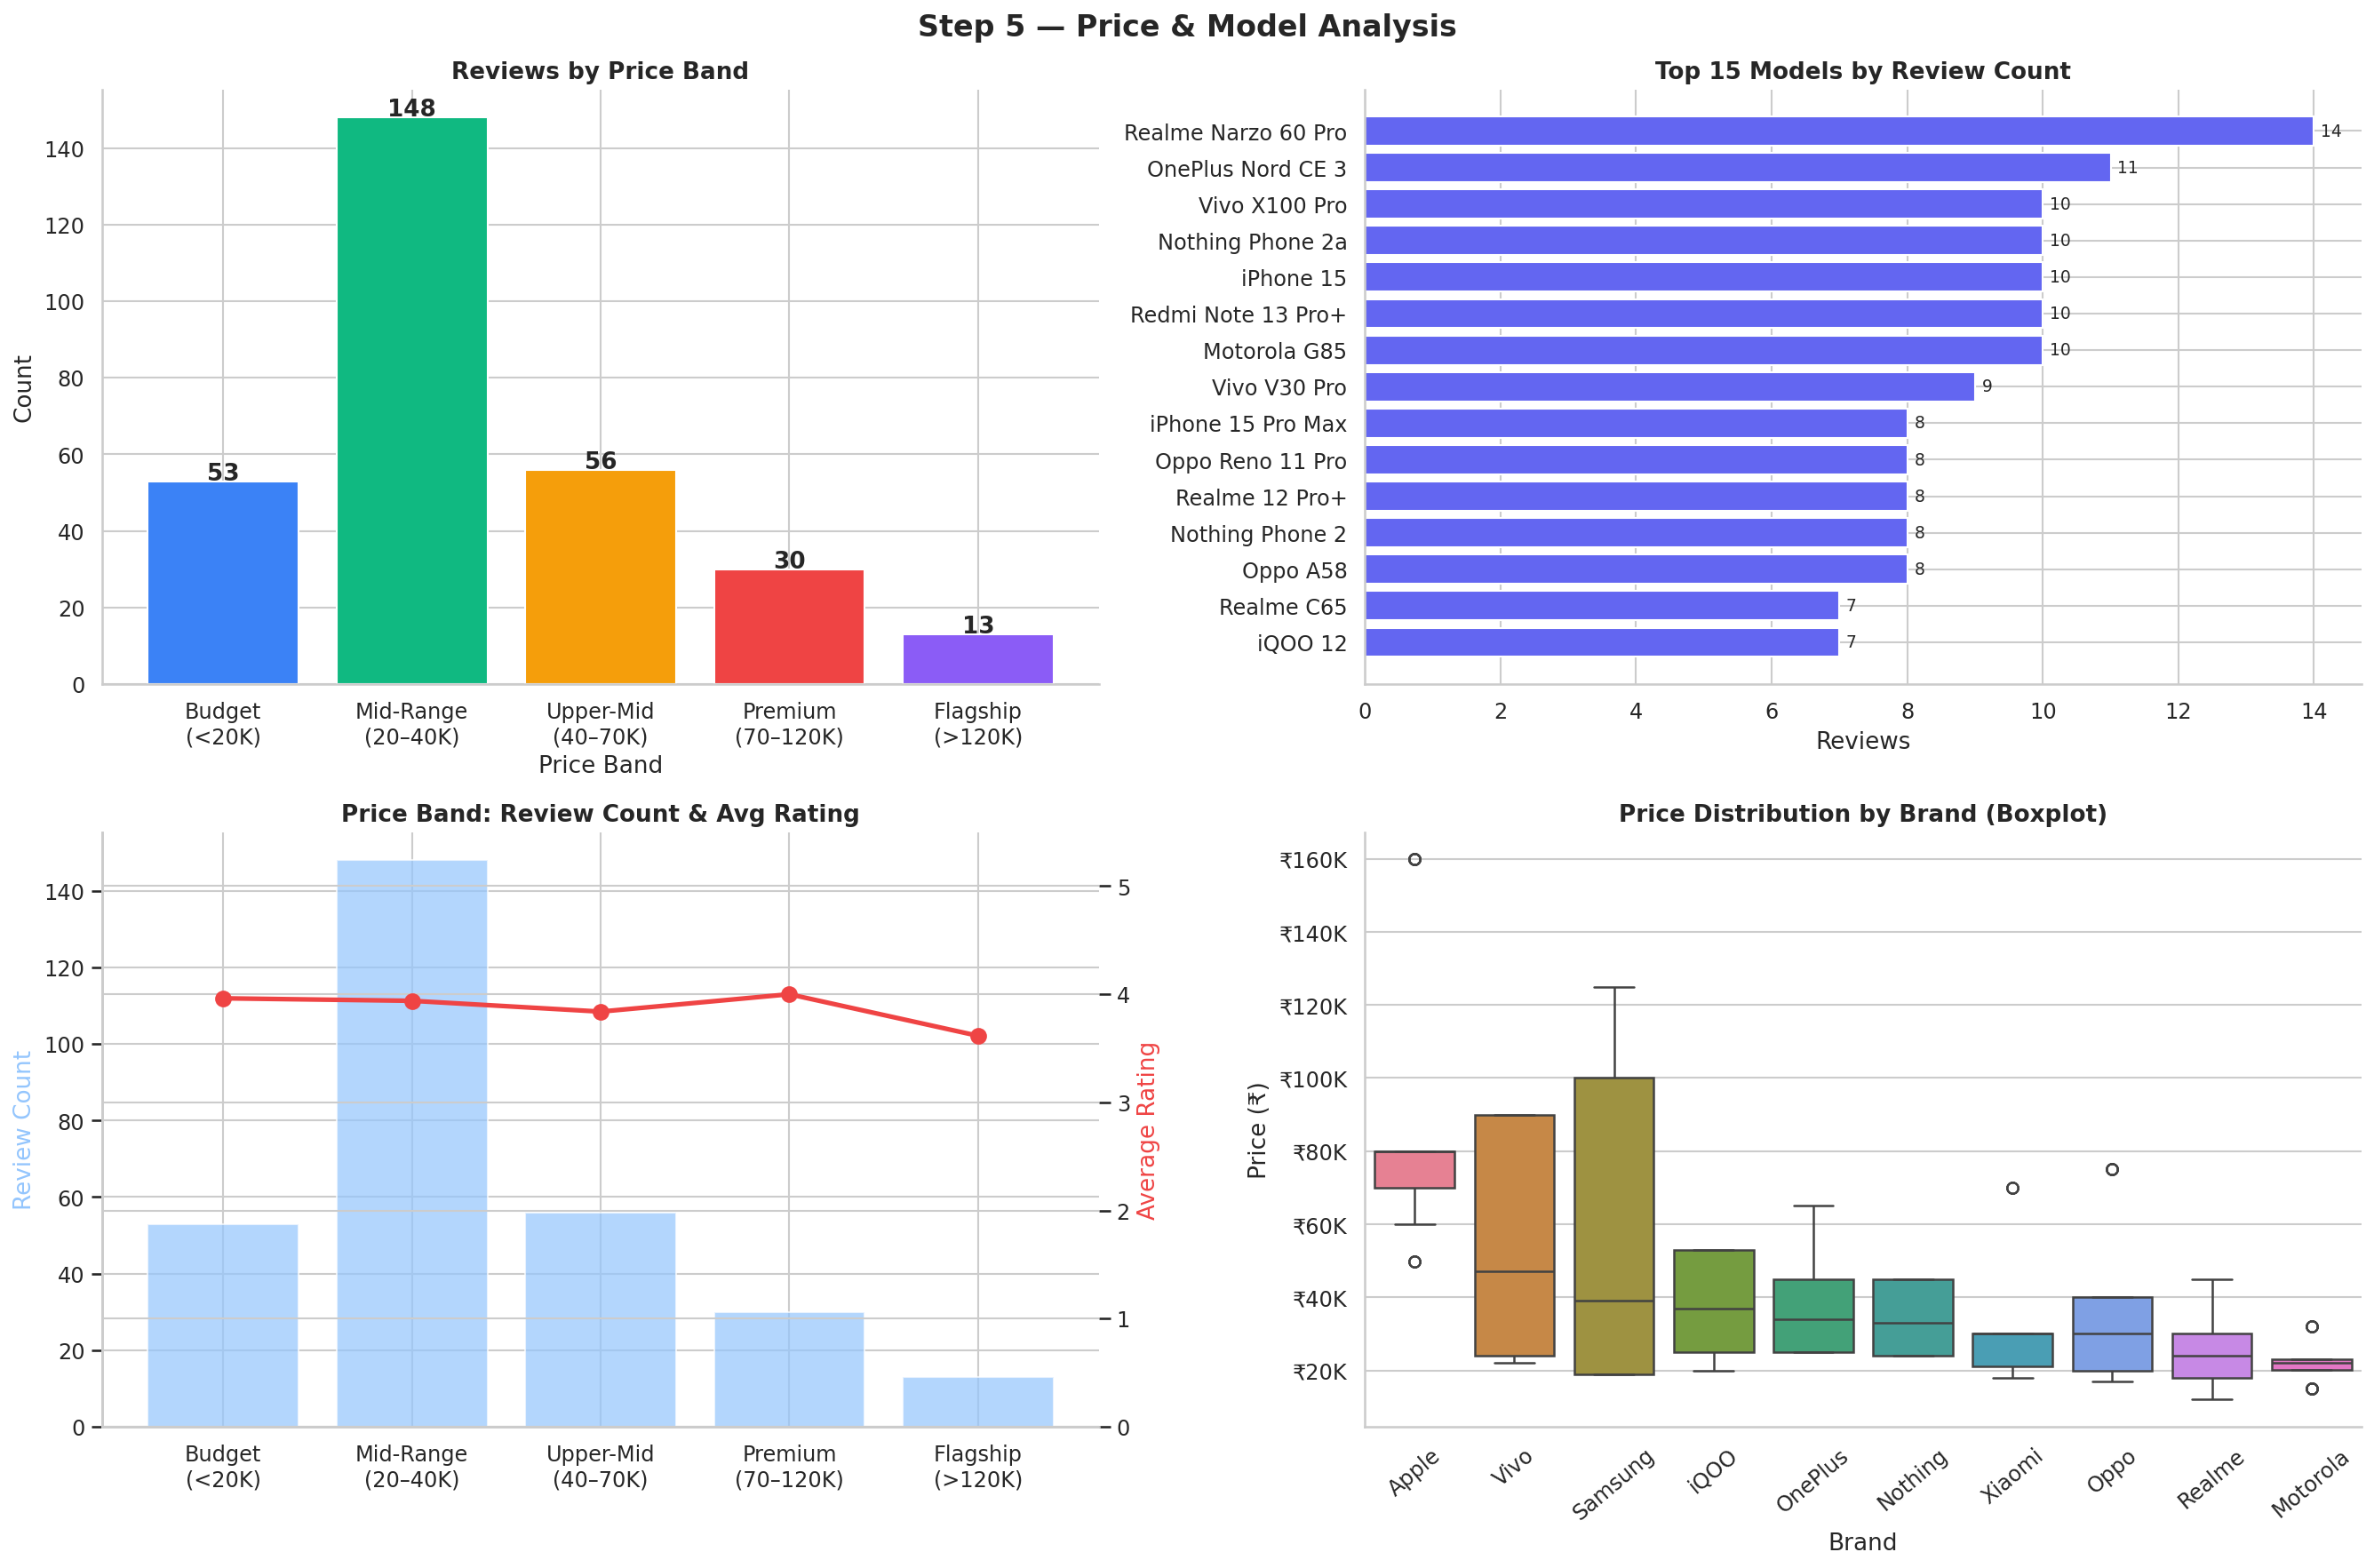

  ✓ step5_price_model.png


In [ ]:
print("STEP 5 – Price & Model Analysis")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Step 5 — Price & Model Analysis", fontsize=16, fontweight="bold")

# 5a Price band distribution
ax = axes[0,0]
pb_counts = df["price_band"].value_counts().sort_index()
bars = ax.bar(pb_counts.index.astype(str), pb_counts.values, color=PALETTE[:5], edgecolor="white")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
            str(int(b.get_height())), ha="center", fontweight="bold")
ax.set_title("Reviews by Price Band", fontweight="bold")
ax.set_ylabel("Count"); ax.set_xlabel("Price Band")

# 5b Top 15 models by review count
ax = axes[0,1]
top_models = df["model"].value_counts().head(15)
ax.barh(top_models.index[::-1], top_models.values[::-1], color="#6366F1", edgecolor="white")
for i, v in enumerate(top_models.values[::-1]):
    ax.text(v+0.1, i, str(v), va="center", fontsize=9)
ax.set_title("Top 15 Models by Review Count", fontweight="bold")
ax.set_xlabel("Reviews")

# 5c Price band × avg rating
ax = axes[1,0]
pb_stats = df.groupby("price_band").agg(avg_rating=("rating","mean"), count=("rating","count")).reset_index()
ax2 = ax.twinx()
bars = ax.bar(pb_stats["price_band"].astype(str), pb_stats["count"], color="#93C5FD", alpha=0.7, label="Review Count")
line = ax2.plot(pb_stats["price_band"].astype(str), pb_stats["avg_rating"],
                color="#EF4444", marker="o", linewidth=2.5, markersize=8, label="Avg Rating")
ax.set_title("Price Band: Review Count & Avg Rating", fontweight="bold")
ax.set_ylabel("Review Count", color="#93C5FD")
ax2.set_ylabel("Average Rating", color="#EF4444")
ax2.set_ylim(0, 5.5)

# 5d Box plot: price distribution per brand
ax = axes[1,1]
brand_order2 = df.groupby("brand")["price_inr"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="brand", y="price_inr", ax=ax, order=brand_order2,
            palette="husl", linewidth=1.2)
ax.set_title("Price Distribution by Brand (Boxplot)", fontweight="bold")
ax.set_xlabel("Brand"); ax.set_ylabel("Price (₹)")
ax.tick_params(axis="x", rotation=40)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))

plt.tight_layout()
plt.show()
#plt.savefig(OUT+"step5_price_model.png", bbox_inches="tight")
plt.close()
print("  ✓ step5_price_model.png")


# STEP 6 SENTIMENT & REVIEW TEXT ANALYSIS

STEP 6 – Sentiment & Review Text Analysis


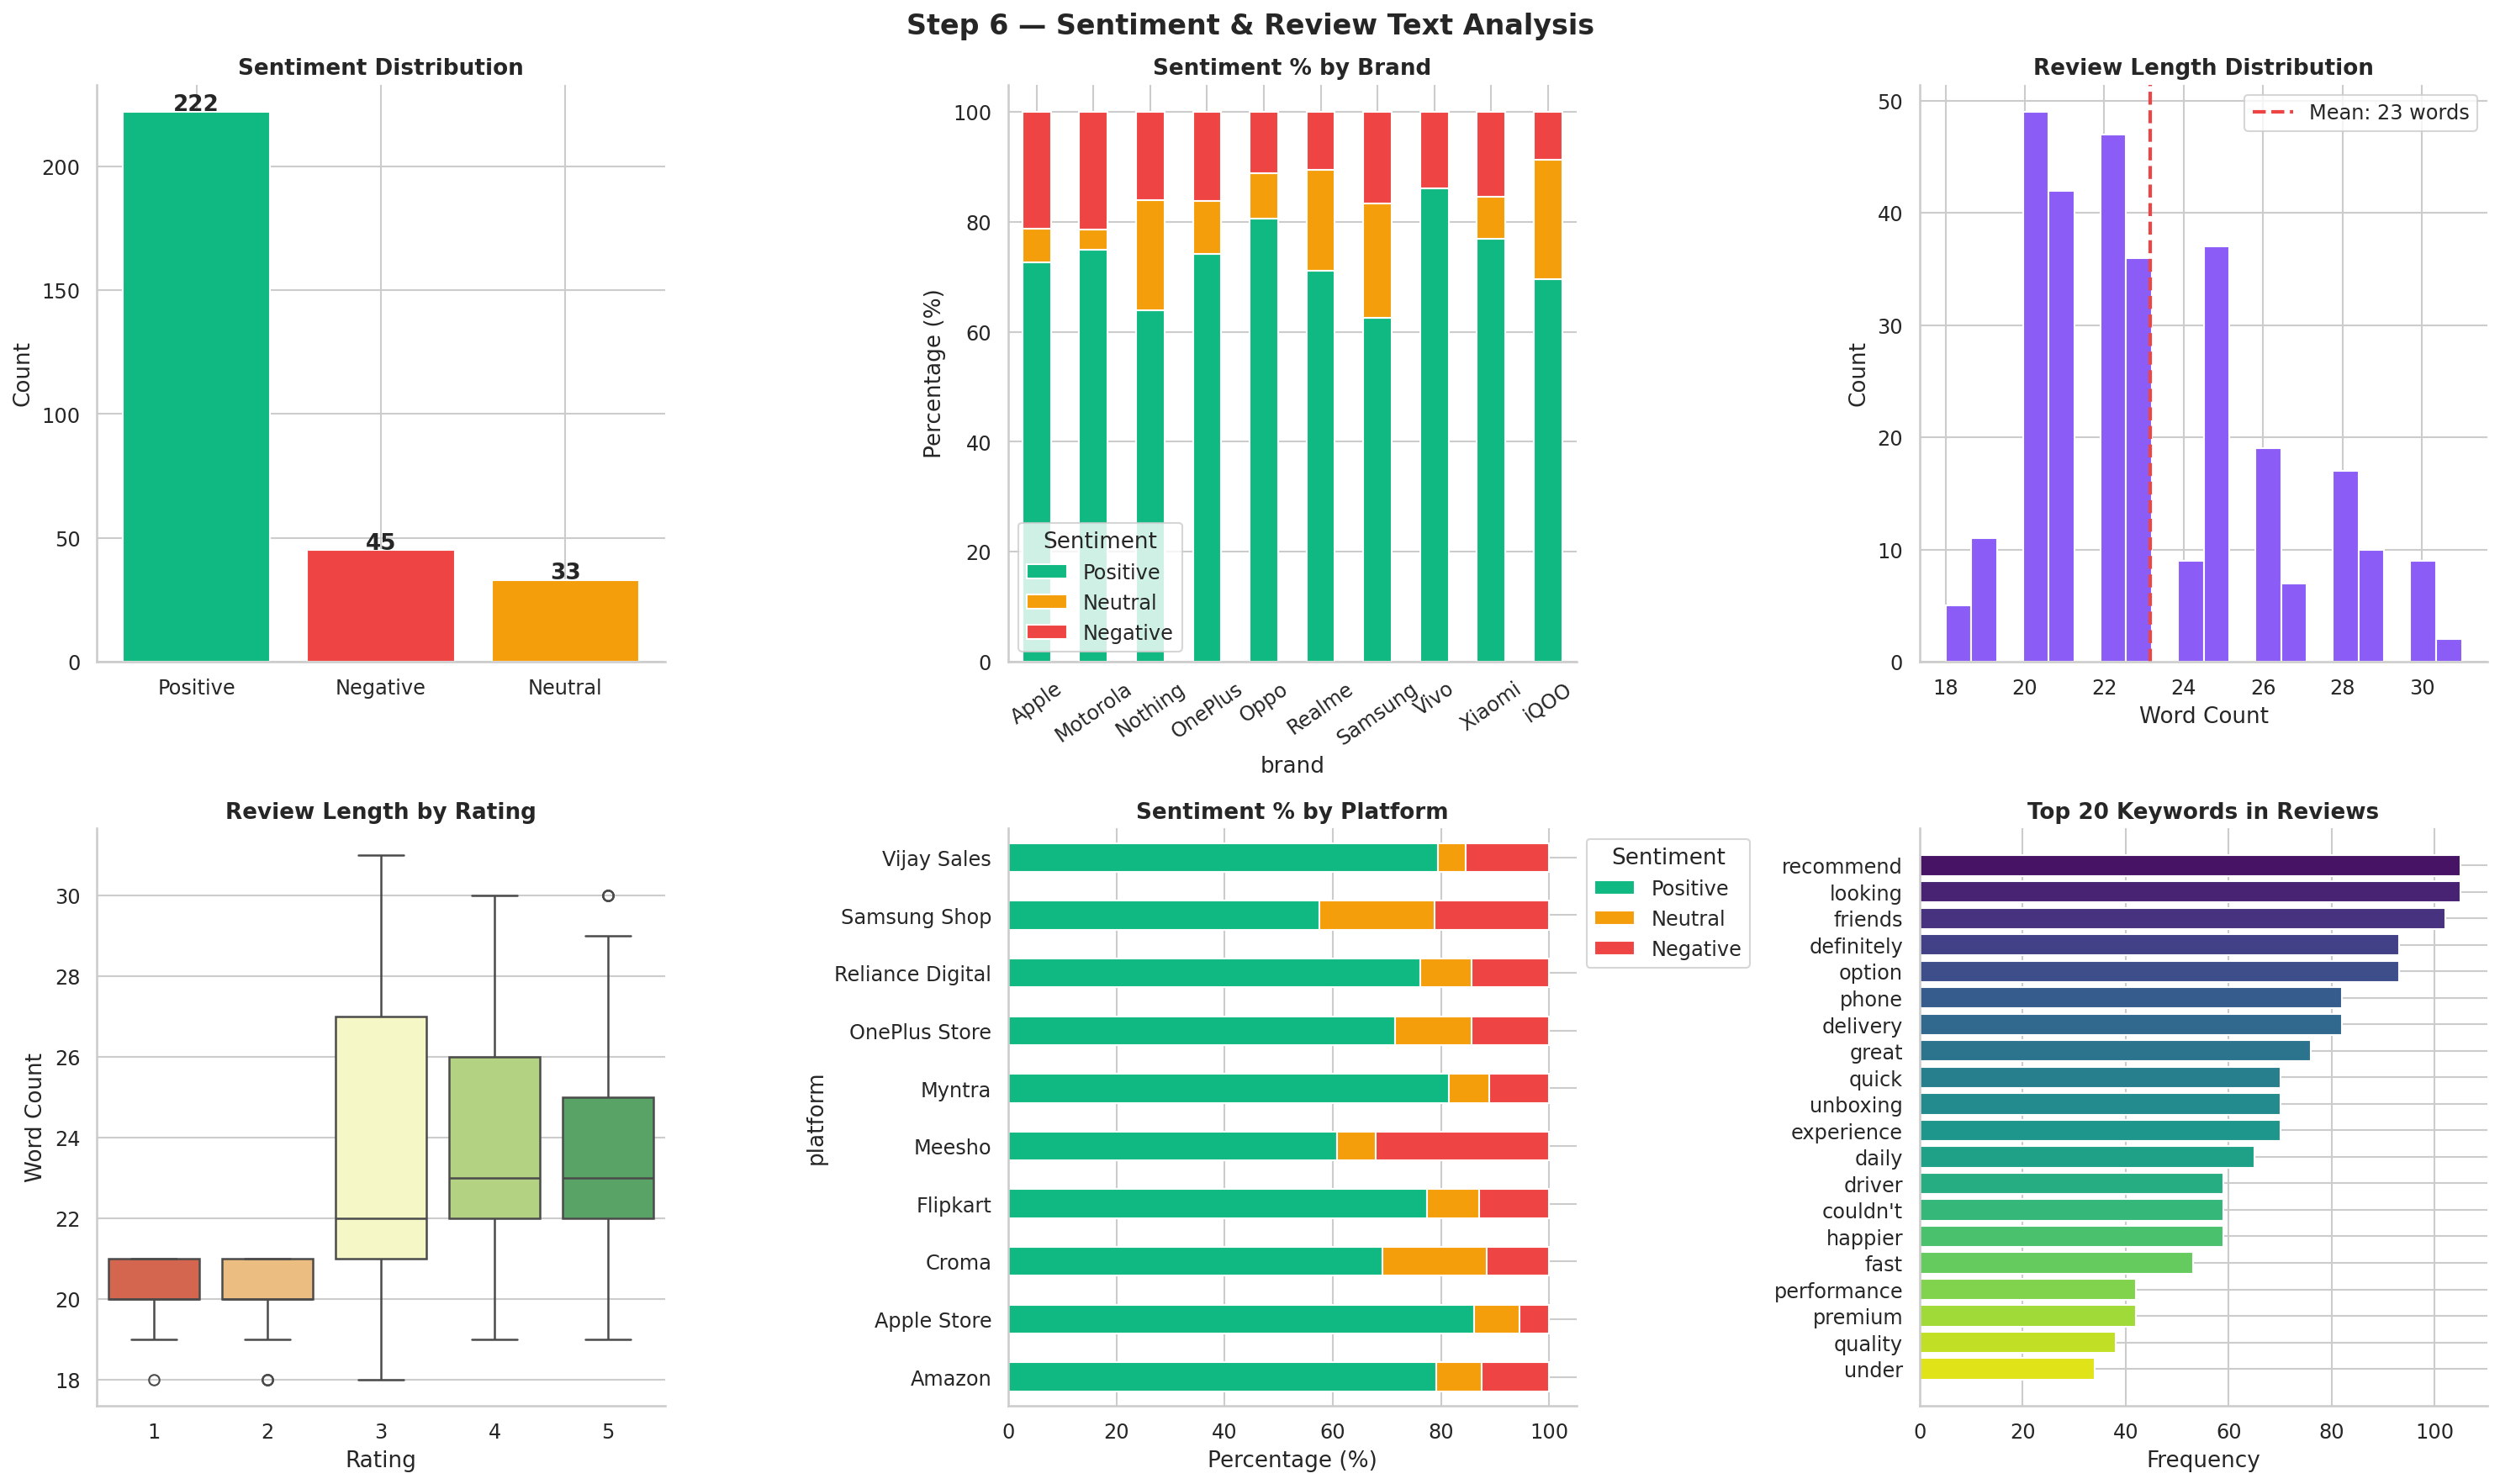

  ✓ step6_sentiment_text.png


In [ ]:
print("STEP 6 – Sentiment & Review Text Analysis")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Step 6 — Sentiment & Review Text Analysis", fontsize=16, fontweight="bold")

# 6a Sentiment distribution
ax = axes[0,0]
sent = df["sentiment"].value_counts()
colors_s = {"Positive":"#10B981","Neutral":"#F59E0B","Negative":"#EF4444"}
bars = ax.bar(sent.index, sent.values, color=[colors_s[s] for s in sent.index], edgecolor="white")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
            str(int(b.get_height())), ha="center", fontweight="bold")
ax.set_title("Sentiment Distribution", fontweight="bold")
ax.set_ylabel("Count")

# 6b Sentiment by brand
ax = axes[0,1]
sent_brand = df.groupby(["brand","sentiment"]).size().unstack(fill_value=0)
sent_brand_pct = sent_brand.div(sent_brand.sum(axis=1), axis=0) * 100
sent_brand_pct[["Positive","Neutral","Negative"]].plot(kind="bar", stacked=True, ax=ax,
    color=["#10B981","#F59E0B","#EF4444"], edgecolor="white", rot=35)
ax.set_title("Sentiment % by Brand", fontweight="bold")
ax.set_ylabel("Percentage (%)"); ax.legend(title="Sentiment")

# 6c Review length distribution
ax = axes[0,2]
ax.hist(df["review_length"], bins=20, color="#8B5CF6", edgecolor="white")
ax.axvline(df["review_length"].mean(), color="#EF4444", linestyle="--", linewidth=2,
           label=f'Mean: {df["review_length"].mean():.0f} words')
ax.set_title("Review Length Distribution", fontweight="bold")
ax.set_xlabel("Word Count"); ax.set_ylabel("Count")
ax.legend()

# 6d Review length by rating (box)
ax = axes[1,0]
sns.boxplot(data=df, x="rating", y="review_length", ax=ax,
            palette="RdYlGn", linewidth=1.2)
ax.set_title("Review Length by Rating", fontweight="bold")
ax.set_xlabel("Rating"); ax.set_ylabel("Word Count")

# 6e Sentiment by platform
ax = axes[1,1]
sp = df.groupby(["platform","sentiment"]).size().unstack(fill_value=0)
sp_pct = sp.div(sp.sum(axis=1), axis=0)*100
sp_pct[["Positive","Neutral","Negative"]].plot(kind="barh", stacked=True, ax=ax,
    color=["#10B981","#F59E0B","#EF4444"], edgecolor="white")
ax.set_title("Sentiment % by Platform", fontweight="bold")
ax.set_xlabel("Percentage (%)"); ax.legend(title="Sentiment", bbox_to_anchor=(1,1))

# 6f Common keywords (manual frequency)
ax = axes[1,2]
all_words = " ".join(df["review_text"].str.lower()).split()
stopwords = {"the","a","an","is","it","i","my","this","to","and","of","for","in","on",
             "with","was","but","not","at","from","be","as","that","me","are","have","has",
             "they","its","by","so","if","no","do","can","all","we","you","more","even",
             "just","than","very","also","into","would","will","their","been","after",
             "before","much","most","or","any","some","one","when","which","about","up","out"}
filtered = [w.strip(".,!?\"'") for w in all_words if w not in stopwords and len(w)>3]
word_freq = Counter(filtered).most_common(20)
words, freqs = zip(*word_freq)
colors_w = sns.color_palette("viridis", len(words))
ax.barh(list(words)[::-1], list(freqs)[::-1], color=colors_w[::-1])
ax.set_title("Top 20 Keywords in Reviews", fontweight="bold")
ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()
#plt.savefig(OUT+"step6_sentiment_text.png", bbox_inches="tight")
plt.close()
print("  ✓ step6_sentiment_text.png")


# STEP 7 PLATFORM & PURCHASE BEHAVIOR

STEP 7 – Platform & Purchase Behavior


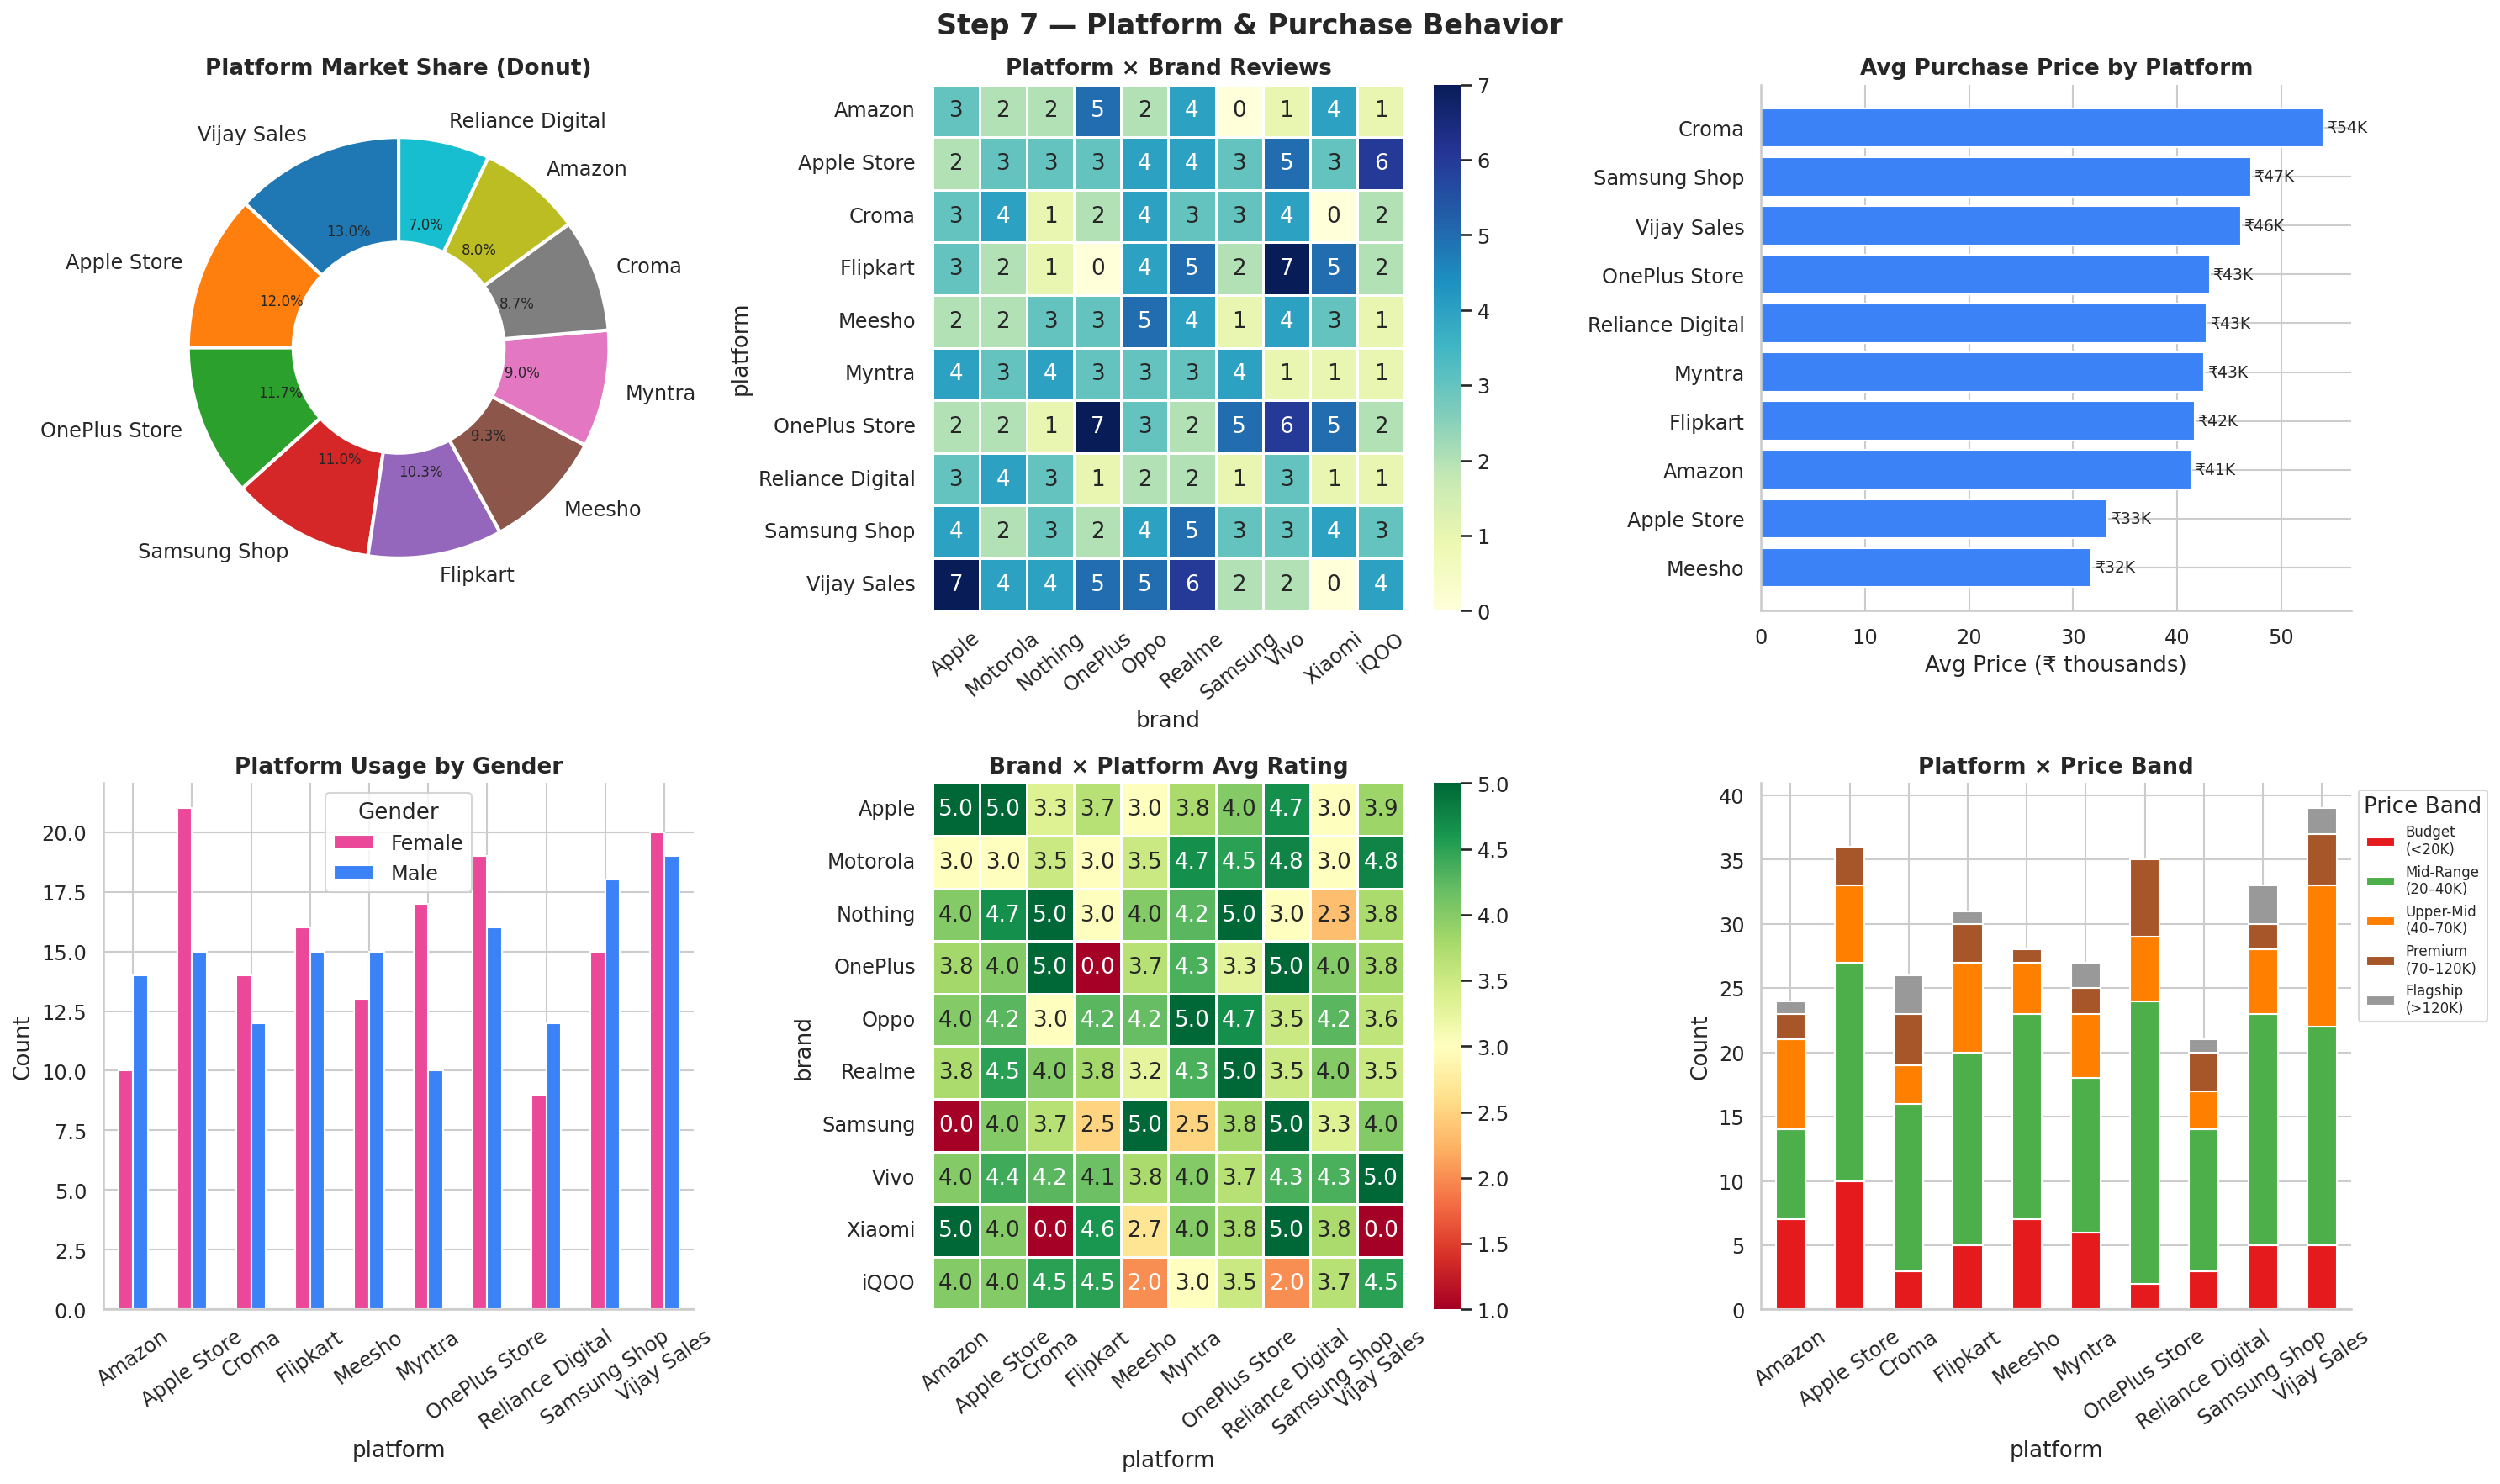

  ✓ step7_platform_behavior.png


In [ ]:
print("STEP 7 – Platform & Purchase Behavior")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Step 7 — Platform & Purchase Behavior", fontsize=16, fontweight="bold")

# 7a Platform market share (donut)
ax = axes[0,0]
plat_counts = df["platform"].value_counts()
wedges, texts, autotexts = ax.pie(plat_counts, labels=plat_counts.index,
    autopct="%1.1f%%", colors=sns.color_palette("tab10", len(plat_counts)),
    startangle=90, wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2))
for t in autotexts: t.set_fontsize(8)
ax.set_title("Platform Market Share (Donut)", fontweight="bold")

# 7b Platform × brand heatmap
ax = axes[0,1]
pb_hm = df.groupby(["platform","brand"]).size().unstack(fill_value=0)
sns.heatmap(pb_hm, annot=True, fmt="d", cmap="YlGnBu", ax=ax,
            linewidths=0.5, linecolor="white")
ax.set_title("Platform × Brand Reviews", fontweight="bold")
ax.tick_params(axis="x", rotation=40)

# 7c Avg price by platform
ax = axes[0,2]
plat_price = df.groupby("platform")["price_inr"].mean().sort_values(ascending=True)/1000
colors_pp = ["#3B82F6"]*len(plat_price)
ax.barh(plat_price.index, plat_price.values, color="#3B82F6", edgecolor="white")
for i, v in enumerate(plat_price.values):
    ax.text(v+0.3, i, f'₹{v:.0f}K', va="center", fontsize=9)
ax.set_title("Avg Purchase Price by Platform", fontweight="bold")
ax.set_xlabel("Avg Price (₹ thousands)")

# 7d Platform × gender
ax = axes[1,0]
pg = df.groupby(["platform","gender"]).size().unstack(fill_value=0)
pg.plot(kind="bar", ax=ax, color=["#EC4899","#3B82F6"], edgecolor="white", rot=35)
ax.set_title("Platform Usage by Gender", fontweight="bold")
ax.set_ylabel("Count"); ax.legend(title="Gender")

# 7e Brand × platform avg rating
ax = axes[1,1]
bp_rating = df.groupby(["brand","platform"])["rating"].mean().unstack(fill_value=0)
sns.heatmap(bp_rating, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax,
            linewidths=0.5, linecolor="white", vmin=1, vmax=5)
ax.set_title("Brand × Platform Avg Rating", fontweight="bold")
ax.tick_params(axis="x", rotation=40)

# 7f Platform × price band
ax = axes[1,2]
ppb = df.groupby(["platform","price_band"]).size().unstack(fill_value=0)
ppb.plot(kind="bar", stacked=True, ax=ax, colormap="Set1", edgecolor="white", rot=35)
ax.set_title("Platform × Price Band", fontweight="bold")
ax.set_ylabel("Count"); ax.legend(title="Price Band", bbox_to_anchor=(1,1), fontsize=8)

plt.tight_layout()
plt.show()
#plt.savefig(OUT+"step7_platform_behavior.png", bbox_inches="tight")
plt.close()
print("  ✓ step7_platform_behavior.png")


# STEP 8 CORRELATION & STATISTICAL ANALYSIS

STEP 8 – Correlation & Statistical Analysis


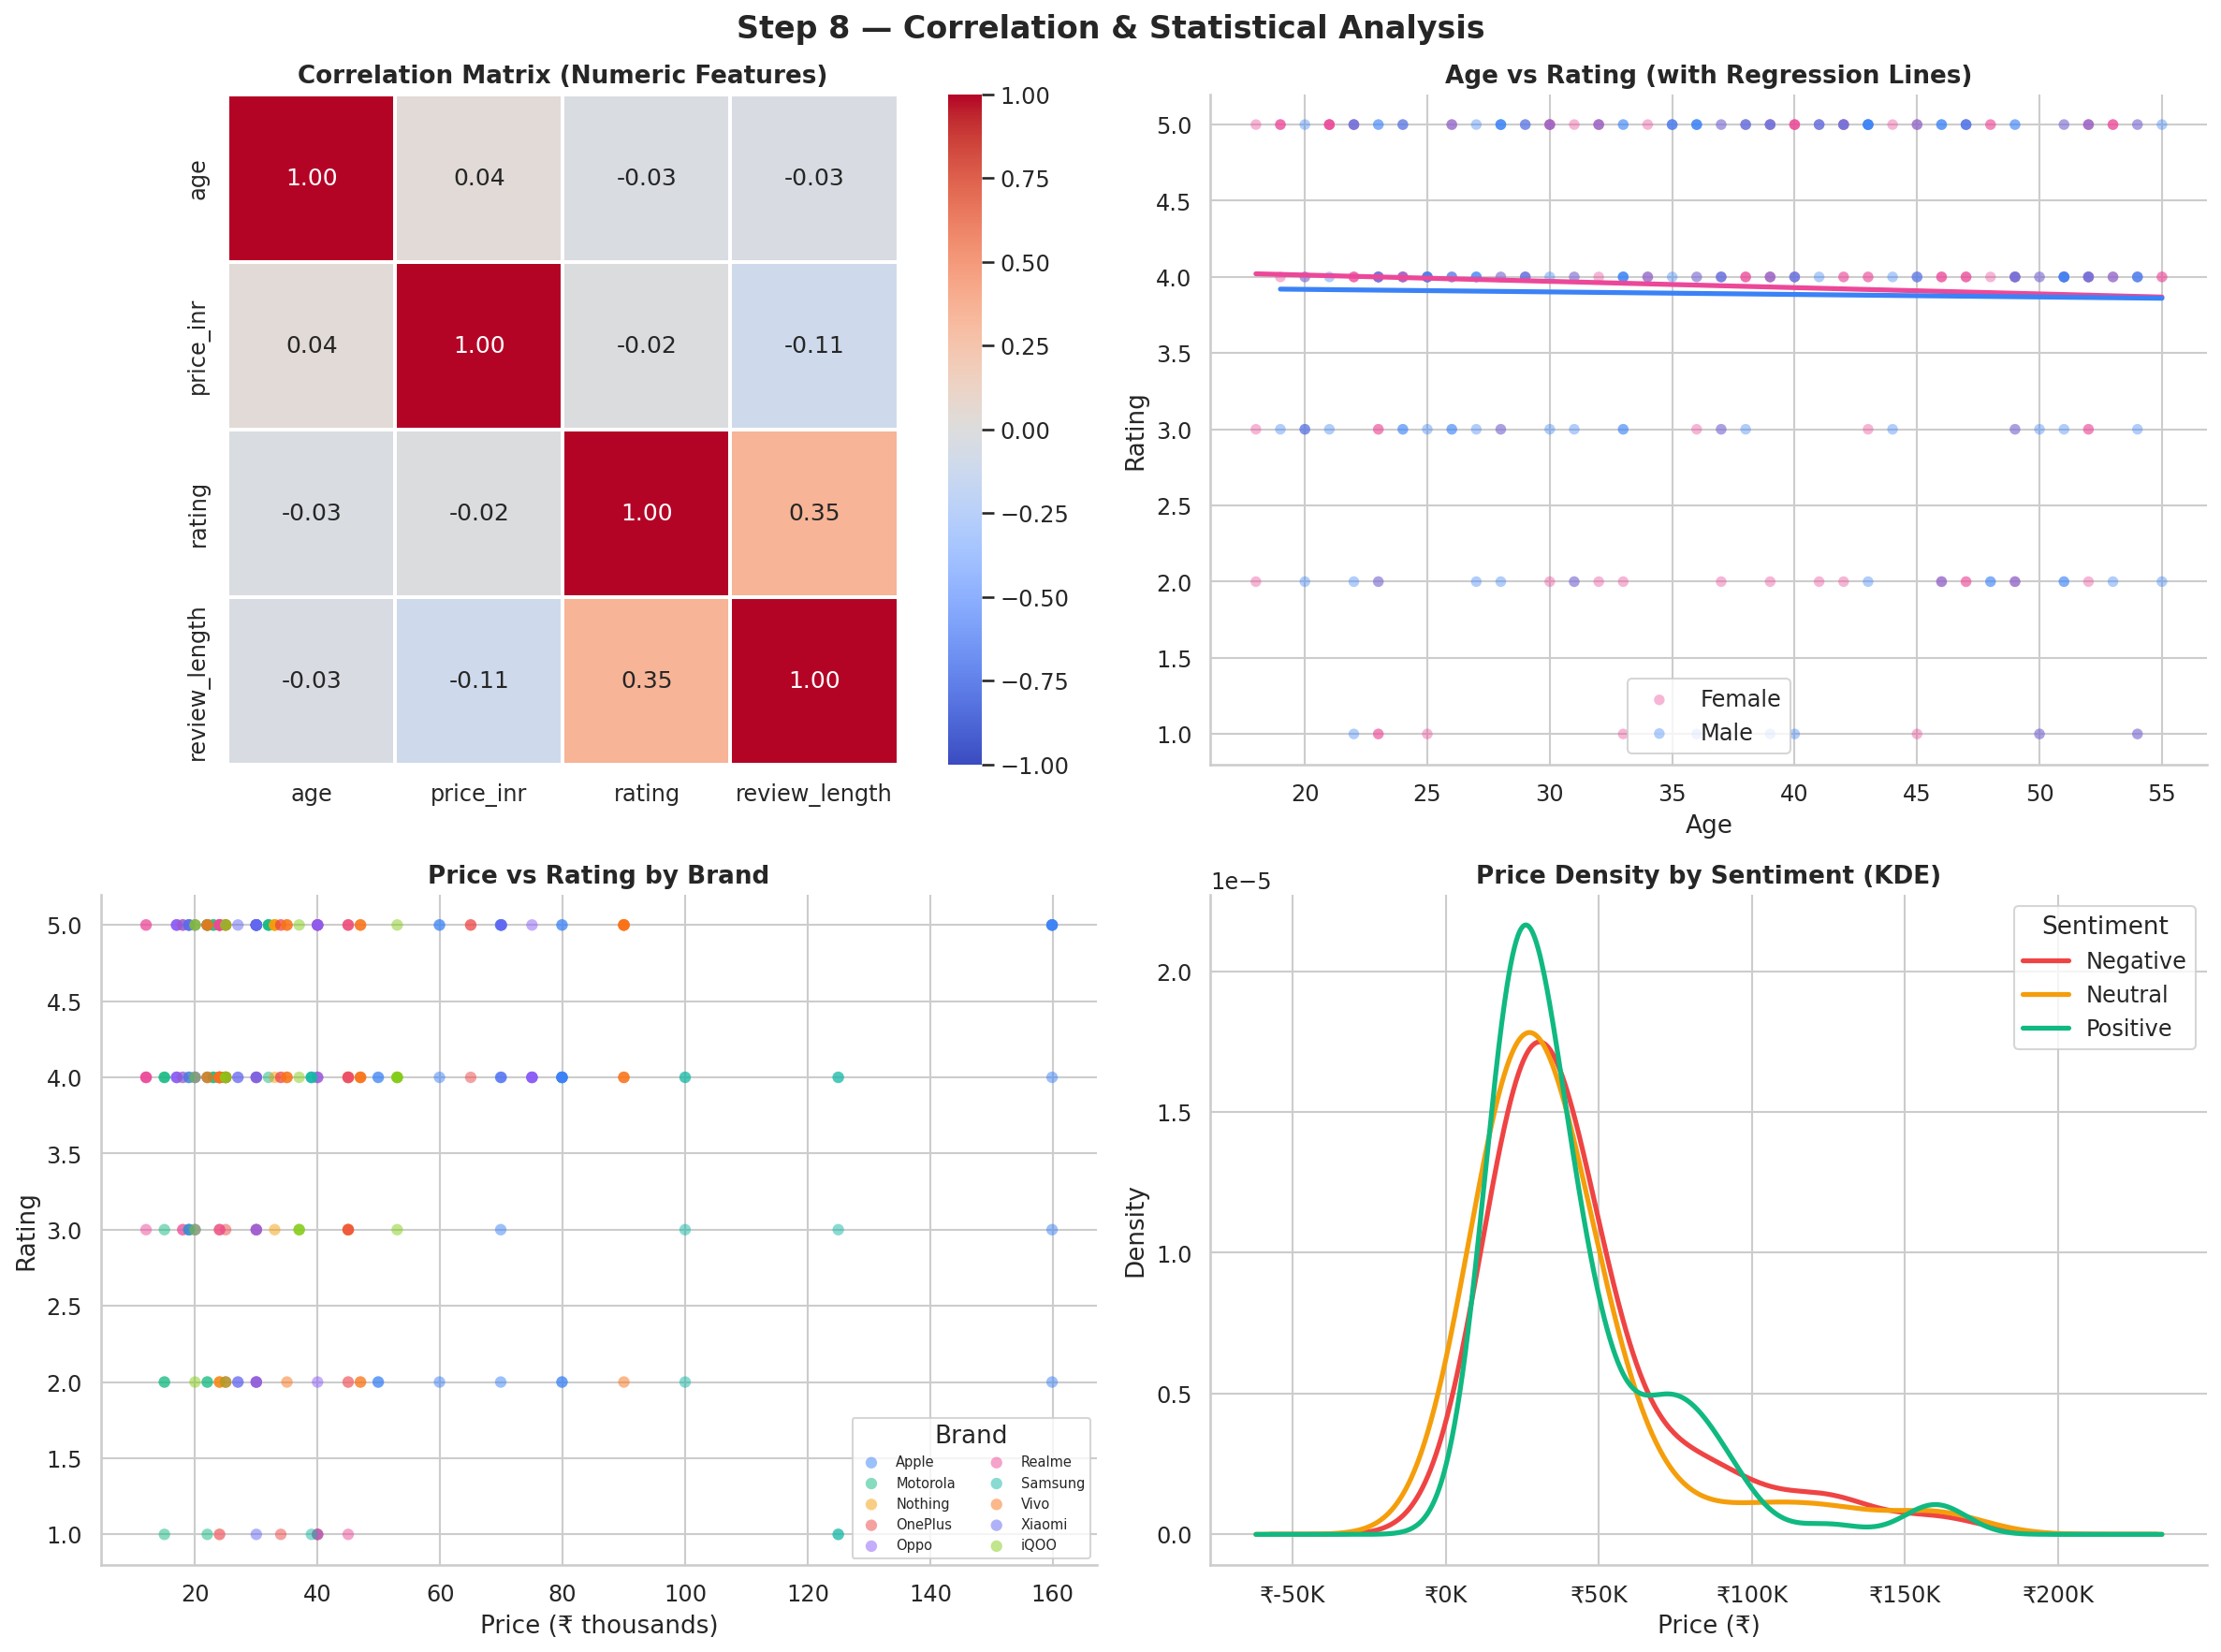

  ✓ step8_correlation_stats.png


In [ ]:
print("STEP 8 – Correlation & Statistical Analysis")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Step 8 — Correlation & Statistical Analysis", fontsize=16, fontweight="bold")

# 8a Correlation heatmap
ax = axes[0,0]
num_cols = ["age","price_inr","rating","review_length"]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax,
            linewidths=1, linecolor="white", vmin=-1, vmax=1,
            square=True, annot_kws={"size":12})
ax.set_title("Correlation Matrix (Numeric Features)", fontweight="bold")

# 8b Age vs rating scatter with regression
ax = axes[0,1]
for g, grp in df.groupby("gender"):
    ax.scatter(grp["age"], grp["rating"], alpha=0.4, label=g,
               color=gender_colors[g], s=30, edgecolors="none")
    z = np.polyfit(grp["age"], grp["rating"], 1)
    p = np.poly1d(z)
    xs = np.linspace(grp["age"].min(), grp["age"].max(), 100)
    ax.plot(xs, p(xs), linewidth=2.5, color=gender_colors[g])
ax.set_title("Age vs Rating (with Regression Lines)", fontweight="bold")
ax.set_xlabel("Age"); ax.set_ylabel("Rating")
ax.legend()

# 8c Price vs rating per brand
ax = axes[1,0]
for i, (brand, grp) in enumerate(df.groupby("brand")):
    ax.scatter(grp["price_inr"]/1000, grp["rating"], alpha=0.5,
               label=brand, color=PALETTE[i % len(PALETTE)], s=35, edgecolors="none")
ax.set_title("Price vs Rating by Brand", fontweight="bold")
ax.set_xlabel("Price (₹ thousands)"); ax.set_ylabel("Rating")
ax.legend(title="Brand", fontsize=7, ncol=2)

# 8d KDE plot: rating density by sentiment
ax = axes[1,1]
sent_colors = {"Positive":"#10B981","Neutral":"#F59E0B","Negative":"#EF4444"}
for s, grp in df.groupby("sentiment"):
    grp["price_inr"].plot.kde(ax=ax, label=s, color=sent_colors[s], linewidth=2.5)
ax.set_title("Price Density by Sentiment (KDE)", fontweight="bold")
ax.set_xlabel("Price (₹)"); ax.set_ylabel("Density")
ax.legend(title="Sentiment")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))

plt.tight_layout()
plt.show()
#plt.savefig(OUT+"step8_correlation_stats.png", bbox_inches="tight")
plt.close()
print("  ✓ step8_correlation_stats.png")


# STEP 9 BRAND PERFORMANCE SCORECARD

STEP 9 – Brand Performance Scorecard


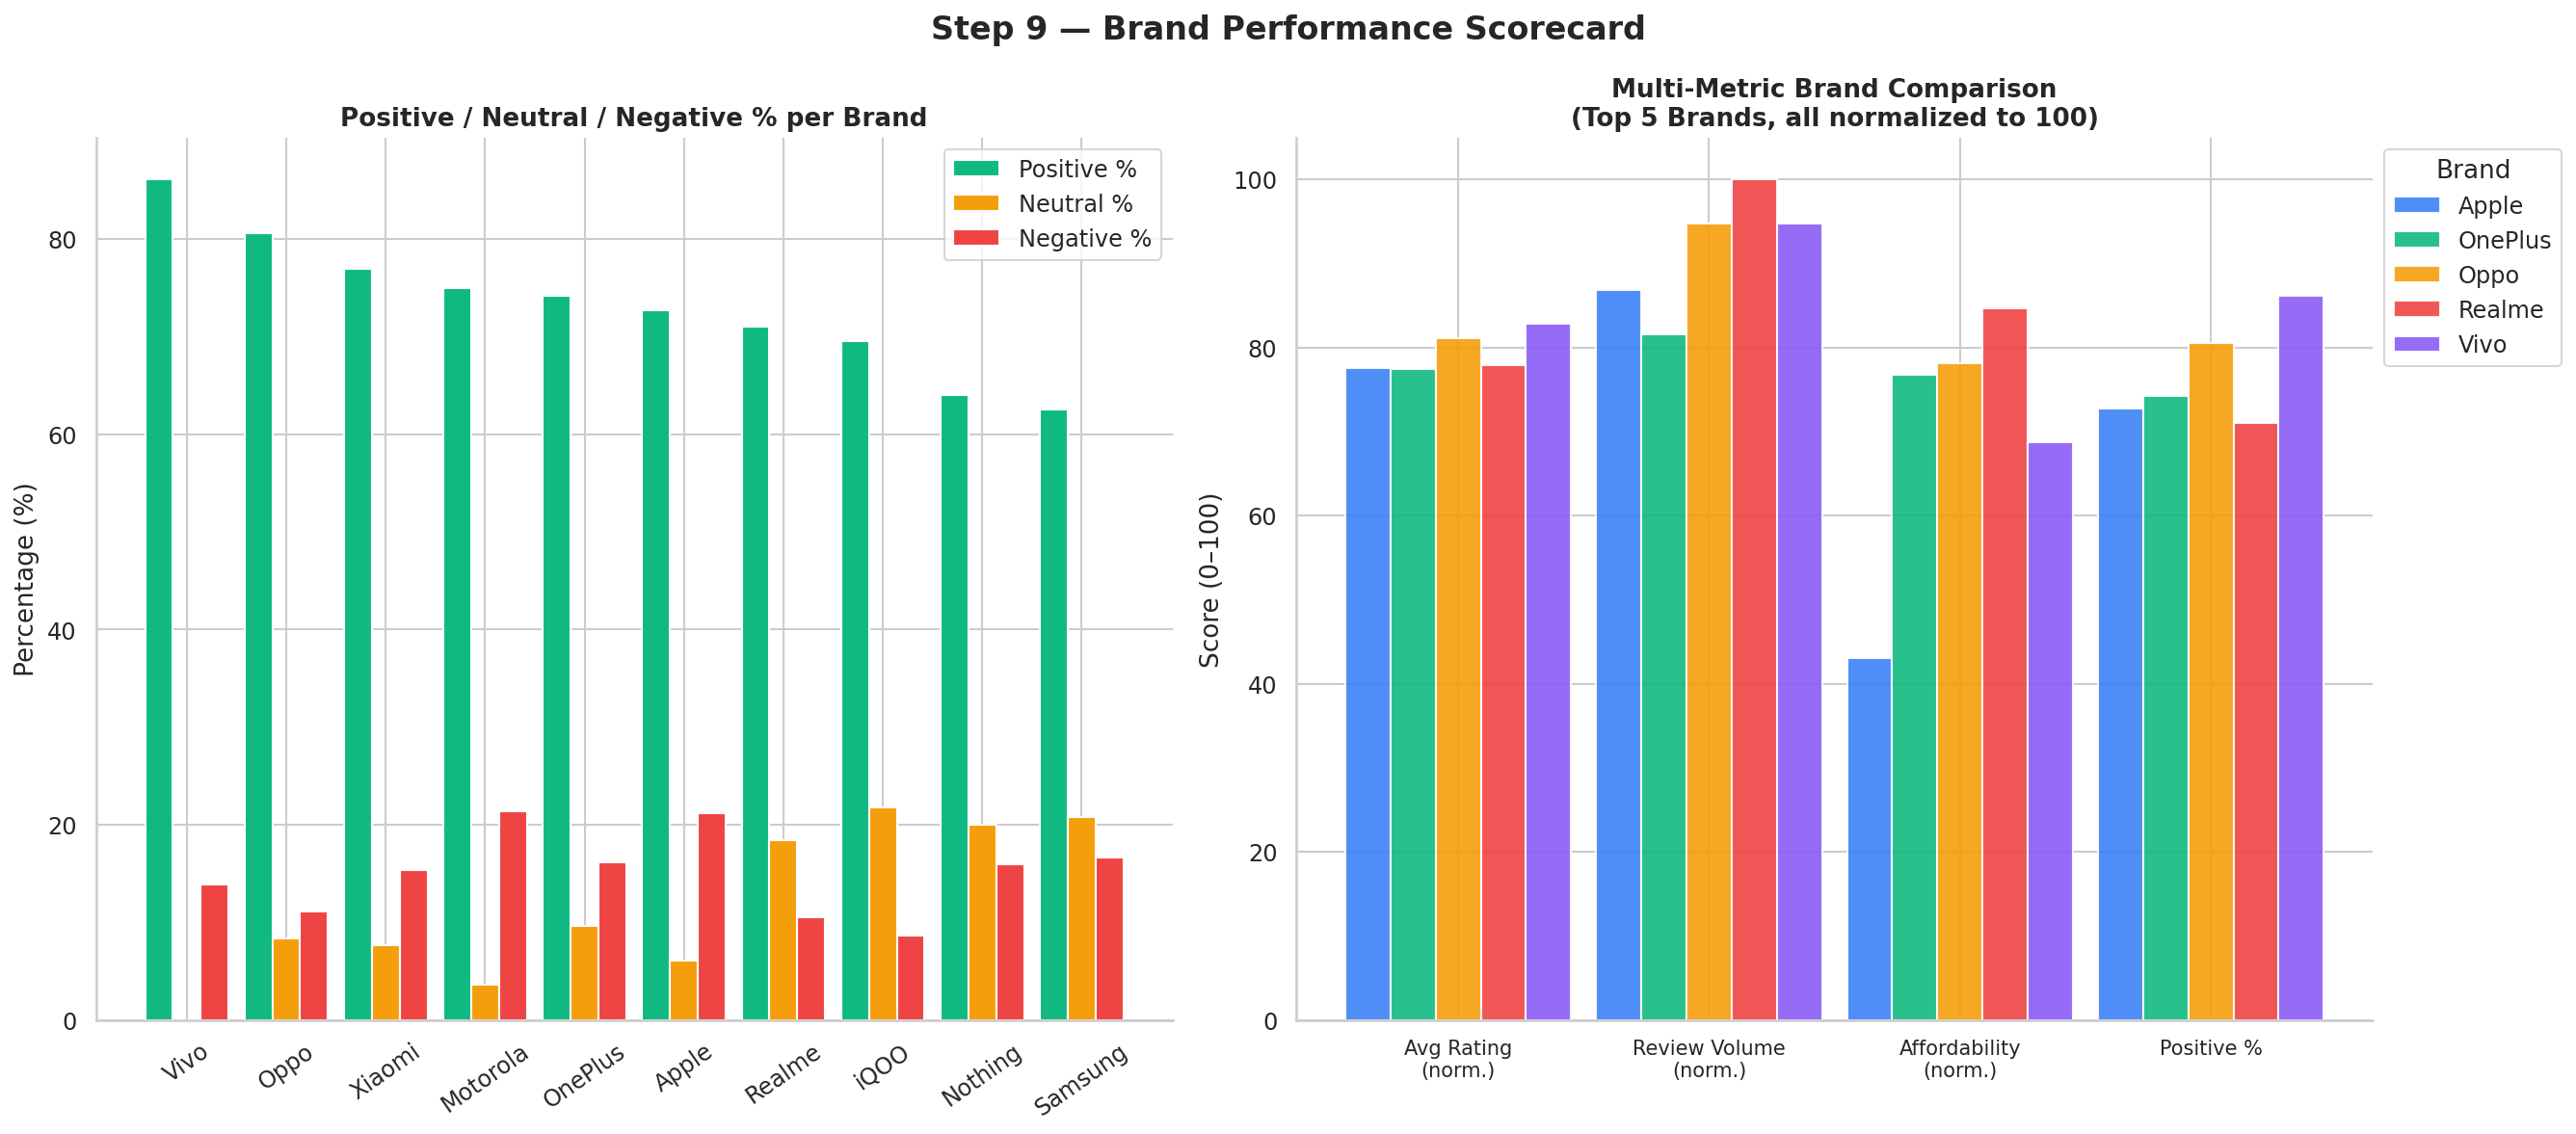

  ✓ step9_brand_scorecard.png


In [ ]:
print("STEP 9 – Brand Performance Scorecard")

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Step 9 — Brand Performance Scorecard", fontsize=16, fontweight="bold")

# 9a Grouped bar: positive vs negative rate by brand
ax = axes[0]
brand_sent = df.groupby("brand")["sentiment"].value_counts(normalize=True).unstack(fill_value=0)*100
brand_sent_sorted = brand_sent.sort_values("Positive", ascending=False)
x = np.arange(len(brand_sent_sorted))
w = 0.28
ax.bar(x-w, brand_sent_sorted.get("Positive",0), w, label="Positive %", color="#10B981", edgecolor="white")
ax.bar(x, brand_sent_sorted.get("Neutral",0), w, label="Neutral %", color="#F59E0B", edgecolor="white")
ax.bar(x+w, brand_sent_sorted.get("Negative",0), w, label="Negative %", color="#EF4444", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(brand_sent_sorted.index, rotation=35)
ax.set_title("Positive / Neutral / Negative % per Brand", fontweight="bold")
ax.set_ylabel("Percentage (%)"); ax.legend()

# 9b Radar-like summary: multi-metric brand comparison (top 5)
ax = axes[1]
top5_brands = df["brand"].value_counts().head(5).index
metrics_df = df[df["brand"].isin(top5_brands)].groupby("brand").agg(
    avg_rating=("rating","mean"),
    review_vol=("rating","count"),
    avg_price=("price_inr","mean"),
    pos_rate=("sentiment", lambda x: (x=="Positive").mean()*100)
).reset_index()

x2 = np.arange(len(metrics_df))
fig2, ax2 = plt.subplots(figsize=(10,6))  # separate for clarity; re-use ax
ax.clear()

width = 0.18
colors5 = PALETTE[:5]
for i, (_, row) in enumerate(metrics_df.iterrows()):
    offset = (i - 2) * width
    bars_vals = [
        row["avg_rating"]/5*100,
        row["review_vol"]/df["brand"].value_counts().max()*100,
        (1-row["avg_price"]/df["price_inr"].max())*100,
        row["pos_rate"]
    ]
    ax.bar(np.arange(4)+offset, bars_vals, width=width,
           label=row["brand"], color=colors5[i], edgecolor="white", alpha=0.9)

ax.set_xticks(np.arange(4))
ax.set_xticklabels(["Avg Rating\n(norm.)", "Review Volume\n(norm.)", "Affordability\n(norm.)", "Positive %"], fontsize=10)
ax.set_title("Multi-Metric Brand Comparison\n(Top 5 Brands, all normalized to 100)", fontweight="bold")
ax.set_ylabel("Score (0–100)")
ax.legend(title="Brand", bbox_to_anchor=(1,1))
plt.close(fig2)

plt.tight_layout()
#plt.savefig(OUT+"step9_brand_scorecard.png", bbox_inches="tight")
plt.show()
plt.close()
print("  ✓ step9_brand_scorecard.png")


# STEP 10 PAIRPLOT & ADVANCED MULTIVARIATE

STEP 10 – Pairplot & Advanced Multivariate


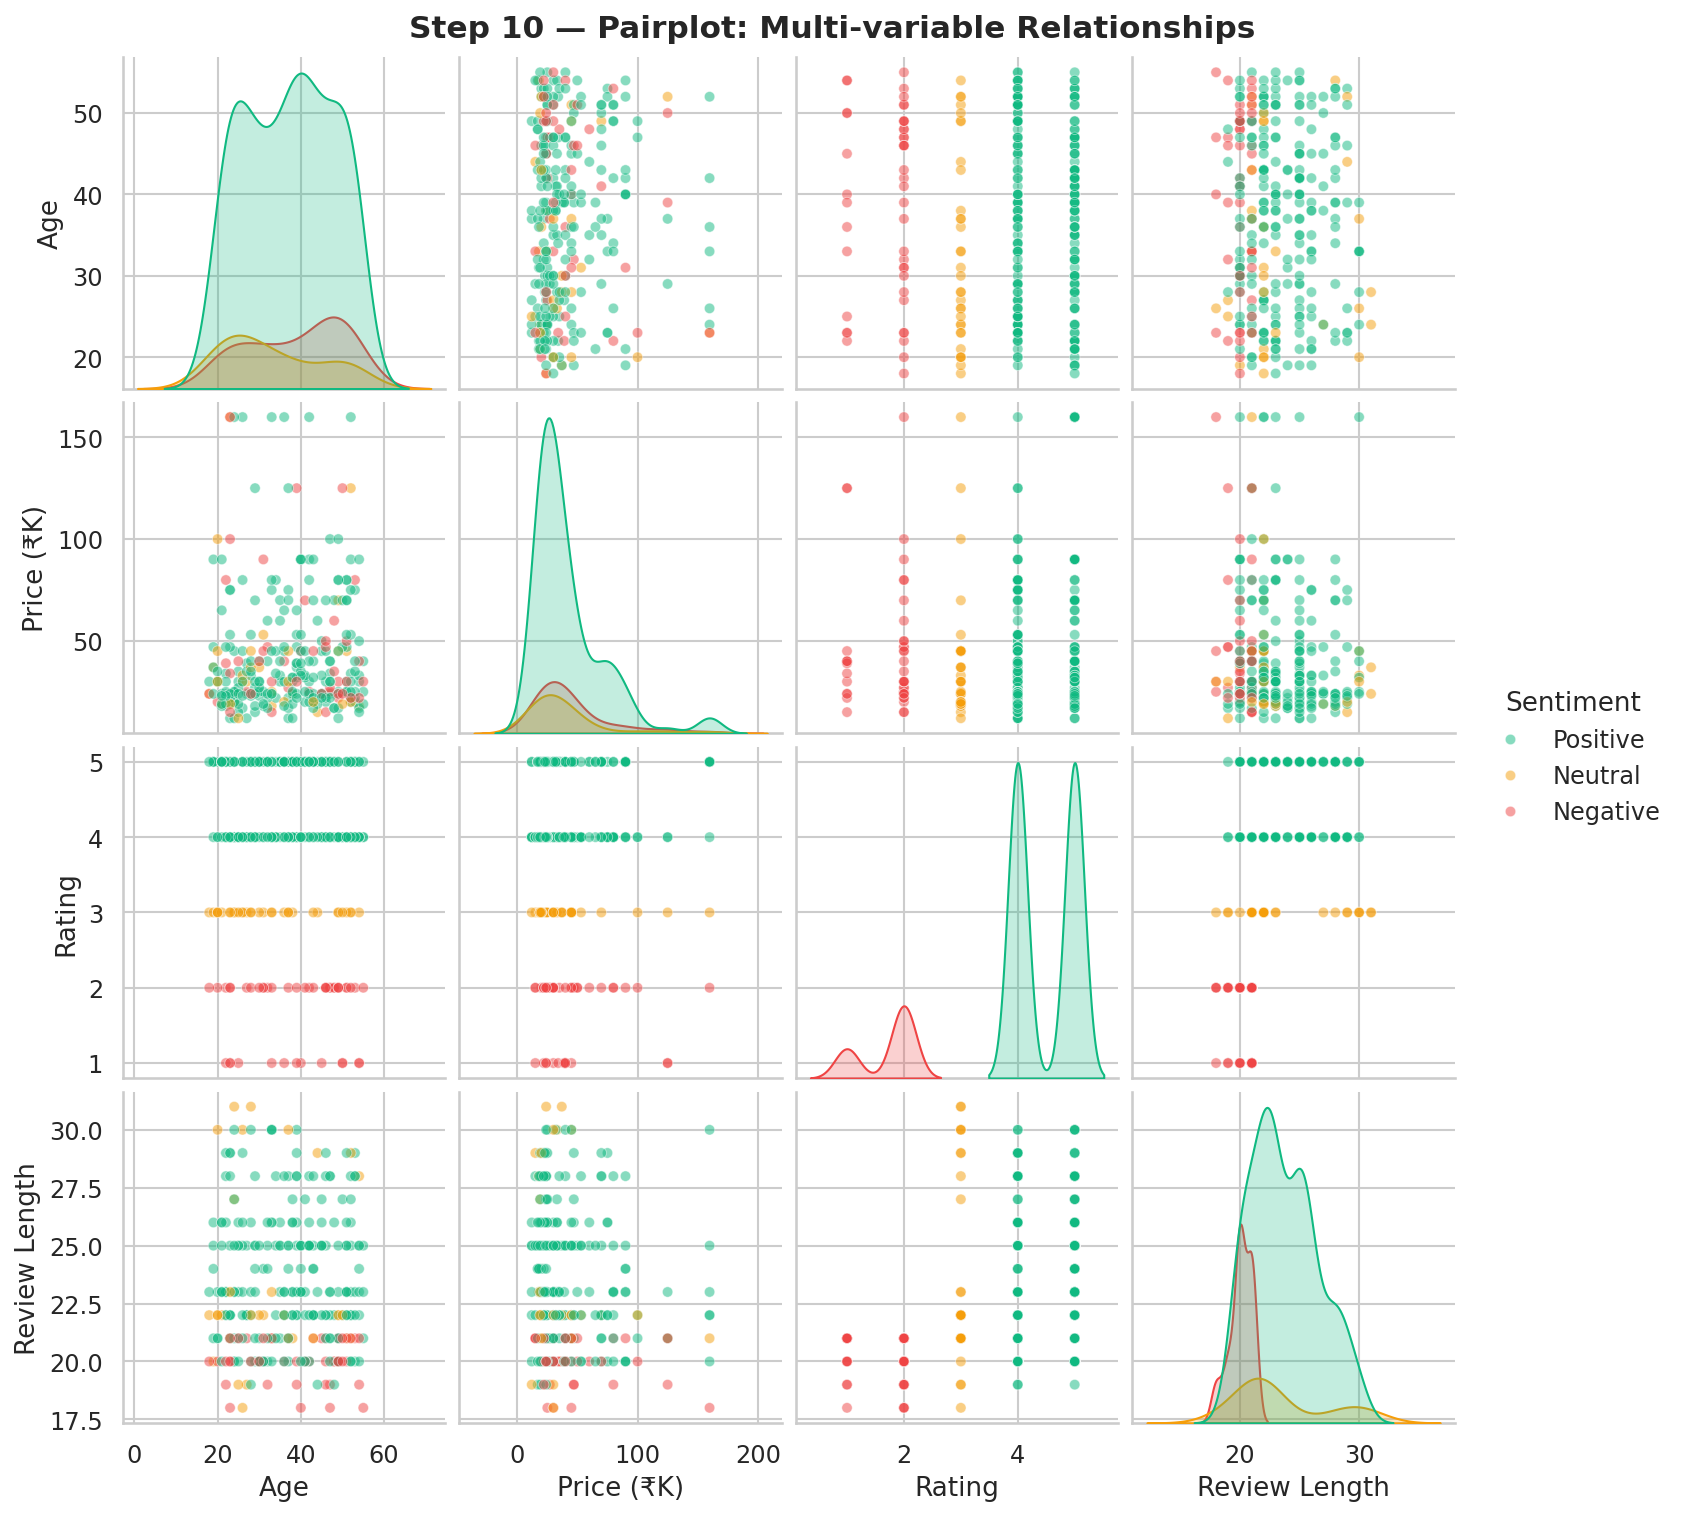

  ✓ step10_pairplot.png

All 10 steps complete — 10 charts saved to /mnt/user-data/outputs/


In [ ]:
print("STEP 10 – Pairplot & Advanced Multivariate")

# Pairplot
pair_df = df[["age","price_inr","rating","review_length","sentiment"]].copy()
pair_df["price_inr"] = pair_df["price_inr"]/1000
pair_df.columns = ["Age","Price (₹K)","Rating","Review Length","Sentiment"]
g = sns.pairplot(pair_df, hue="Sentiment",
                 palette={"Positive":"#10B981","Neutral":"#F59E0B","Negative":"#EF4444"},
                 plot_kws={"alpha":0.5, "s":25},
                 diag_kind="kde", corner=False)
g.fig.suptitle("Step 10 — Pairplot: Multi-variable Relationships", fontsize=15, fontweight="bold", y=1.01)
#plt.savefig(OUT+"step10_pairplot.png", bbox_inches="tight")
plt.show()
plt.close()
print("  ✓ step10_pairplot.png")

print("\nAll 10 steps complete — 10 charts saved to /mnt/user-data/outputs/")
